# Credit Risk Analysis

In [86]:
pip install imblearn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [87]:
pip install icecream


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [88]:
# Importation des librairies
import pandas as pd
import seaborn as sns
import numpy as np
from icecream import ic
from pandas import read_csv
from pandas import set_option

from matplotlib import pyplot as plt

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline 

from collections import Counter

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import  RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import  GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.metrics import precision_score
from sklearn.metrics import make_scorer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate



## Collecte initiale des données

In [89]:
# Collecte des données à analyser
credit_filename = 'data/credit.csv'

try:
    credit_df = read_csv(credit_filename)
    print("L'importation des données de crédit à bien fonctionné")
except Exception as e:
    print("Une erreur est survenue dans l'importation des données de crédit")

credit_df_copy = credit_df.copy()


L'importation des données de crédit à bien fonctionné


## Credit.csv

### Description des données de credit.csv

In [90]:
# Affichages des informations du dataset
credit_df_copy.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    int64  
 1   Age             690 non-null    float64
 2   Debt            690 non-null    float64
 3   Married         690 non-null    int64  
 4   BankCustomer    690 non-null    int64  
 5   Industry        690 non-null    object 
 6   Ethnicity       690 non-null    object 
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    int64  
 9   Employed        690 non-null    int64  
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    int64  
 12  Citizen         690 non-null    object 
 13  ZipCode         690 non-null    int64  
 14  Income          690 non-null    int64  
 15  Approved        690 non-null    int64  
dtypes: float64(3), int64(10), object(3)
memory usage: 86.4+ KB


In [91]:
#Affichage du nombre de valeurs égale à '?' par attribut dans le dataset credit.csv
(credit_df_copy == '?').sum()

Gender            0
Age               0
Debt              0
Married           0
BankCustomer      0
Industry          0
Ethnicity         0
YearsEmployed     0
PriorDefault      0
Employed          0
CreditScore       0
DriversLicense    0
Citizen           0
ZipCode           0
Income            0
Approved          0
dtype: int64

In [92]:
# affichage des valeurs manquantes par attribut dans le dataset credit.csv
credit_df_copy.isnull().sum()

Gender            0
Age               0
Debt              0
Married           0
BankCustomer      0
Industry          0
Ethnicity         0
YearsEmployed     0
PriorDefault      0
Employed          0
CreditScore       0
DriversLicense    0
Citizen           0
ZipCode           0
Income            0
Approved          0
dtype: int64

### Prétraitement crédit.csv

#### Prétraitement de 'Industry'

In [93]:
#on va utiliser un encodage onehot etant donnée qu'il n'y a pas d'ordre particulier
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_Industry = encoder.fit_transform(credit_df_copy[['Industry']])
df_encoded_Industry = pd.DataFrame(encoded_Industry, columns=encoder.get_feature_names_out(['Industry']))


#### Prétraitement de 'Ethnicity'

In [94]:
#on va utiliser un encodage onehot etant donnée qu'il n'y a pas d'ordre particulier
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_Ethnicity = encoder.fit_transform(credit_df_copy[['Ethnicity']])
df_encoded_Ethnicity = pd.DataFrame(encoded_Ethnicity, columns=encoder.get_feature_names_out(['Ethnicity']))

#### Prétraitement de 'Citizen'

In [95]:
#on va utiliser un encodage onehot etant donnée qu'il n'y a pas d'ordre particulier
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_Citizen = encoder.fit_transform(credit_df_copy[['Citizen']])
df_encoded_Citizen = pd.DataFrame(encoded_Citizen, columns=encoder.get_feature_names_out(['Citizen']))

#### Prétraitement de 'Income'

In [96]:
# On va vérifier le nombre d'entrée pareil
credit_df_copy.groupby('Income').size().head(20)

Income
0     295
1      29
2       9
3       6
4       5
5       8
6       8
7       4
8       2
9       1
10      4
11      2
12      1
13      2
14      1
15      2
16      2
17      2
18      3
19      2
dtype: int64

In [97]:
#Vérifer l'impact des revenus égale à 0 sur l'approbation
credit_df_copy.groupby((credit_df_copy['Income'] == 0))['Approved'].mean()
#Il n'y a pas vraiment de difference dans le taux de refus/acceptation pour une personne avec zéro comme income vs une personne avec plus de zéro comme income ce qui ne fais pas de sens. Il y a probablement erreur lors de la saisie.


Income
False    0.491139
True     0.383051
Name: Approved, dtype: float64

In [98]:
#Vérifier l'impact entre le revenu égale à 0 et l'attribut employed
credit_df.groupby((credit_df['Income'] == 0))['Employed'].mean()
#Dans 80% des cas quand le income est à 0 les individu sont sans emploi et dans 20% ils ont un emploi

Income
False    0.592405
True     0.206780
Name: Employed, dtype: float64

In [99]:
#verifier l'impact entre le revenu égale à 0 et l'attribut YearsEmployed
mean_worked_years_when_unemployed_and_no_income =credit_df.loc[(credit_df['Income'] == 0) & (credit_df['Employed'] == 0)]['YearsEmployed'].mean().round(2)
print(f"Lorsque l'individu n'a pas d'emploie et n'a pas de revenu, il a travailler en moyenne {mean_worked_years_when_unemployed_and_no_income} années")
# On valide les nombreux cas ou les individus n'ont pas de revenue.

Lorsque l'individu n'a pas d'emploie et n'a pas de revenu, il a travailler en moyenne 1.82 années


In [100]:
#Vérifer l'impact des revenus égale à 1 sur l'approbation
credit_df_copy.groupby((credit_df_copy['Income'] == 1))['Approved'].mean()
#pres de 100% des revenue egale a 1 sont des refusé. 

Income
False    0.461422
True     0.068966
Name: Approved, dtype: float64

##### Y a t'il des cas ou le revenue est égale a zero et l'individu est employé et accumule des années d'emploi?

In [101]:
nb_person_no_income_employed_with_years = credit_df_copy.loc[(credit_df_copy['Income'] == 0) & (credit_df_copy['Employed'] == 1) & (credit_df_copy['YearsEmployed'] != 0)]['Approved'].count()
print(f"Il existe {nb_person_no_income_employed_with_years} entrées dans le dataset de personnes employée depuis une période non nulle qui ont un income qui est de zéro.\nCes entrées doivent être traitées car il s'agit d'erreurs.\n")
print(f"On remplace ces valeurs par NaN et on les traites avec un SimpleImputer avec une stratégie de médiande")

Il existe 59 entrées dans le dataset de personnes employée depuis une période non nulle qui ont un income qui est de zéro.
Ces entrées doivent être traitées car il s'agit d'erreurs.

On remplace ces valeurs par NaN et on les traites avec un SimpleImputer avec une stratégie de médiande


In [102]:
#On remplace les valeurs de Income ciblé par nan
credit_df_copy['Income'] = credit_df_copy['Income'].astype(float)
credit_df_copy.loc[(credit_df_copy['Income'] == 0) & (credit_df_copy['Employed'] == 1) & (credit_df_copy['YearsEmployed'] != 0), 'Income' ] = credit_df_copy.loc[(credit_df_copy['Income'] == 0) & (credit_df_copy['Employed'] == 1) & (credit_df_copy['YearsEmployed'] != 0), 'Income' ].replace(0,np.nan)


In [103]:
ligne_revenu_cible = credit_df_copy.loc[credit_df_copy['Income'].isnull()].head(10)
index_revenu_cible  = ligne_revenu_cible.index
ligne_revenu_cible['Income']

0    NaN
14   NaN
15   NaN
16   NaN
19   NaN
24   NaN
25   NaN
26   NaN
27   NaN
28   NaN
Name: Income, dtype: float64

In [104]:
#On remplace maintenant les occurences de nan avec notre fonction de imputation 
imp_income = SimpleImputer(strategy='median')
credit_df_copy['Income'] = imp_income.fit_transform(credit_df_copy[['Income']])

In [105]:
credit_df_copy.loc[index_revenu_cible]['Income']

0     13.0
14    13.0
15    13.0
16    13.0
19    13.0
24    13.0
25    13.0
26    13.0
27    13.0
28    13.0
Name: Income, dtype: float64

In [106]:
#Concaténation du df final de crédit suite au prétraitement
credit_df_final =pd.concat([credit_df_copy.iloc[:,:5], df_encoded_Industry, df_encoded_Ethnicity, credit_df_copy.iloc[:,7:12], df_encoded_Citizen, credit_df_copy.iloc[:,14:]], axis=1)
credit_df_final
#credit_df_final.to_csv("data/processed/credit_df_final.csv", index=False)

,Gender,Age,Debt,Married,BankCustomer,Industry_CommunicationServices,Industry_ConsumerDiscretionary,Industry_ConsumerStaples,Industry_Education,Industry_Energy,...,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen_ByBirth,Citizen_ByOtherMeans,Citizen_Temporary,Income,Approved
0,1,30.83,0.000,1,1,0.0,0.0,0.0,0.0,0.0,...,1.25,1,1,1,0,1.0,0.0,0.0,13.0,1
1,0,58.67,4.460,1,1,0.0,0.0,0.0,0.0,0.0,...,3.04,1,1,6,0,1.0,0.0,0.0,560.0,1
2,0,24.50,0.500,1,1,0.0,0.0,0.0,0.0,0.0,...,1.50,1,0,0,0,1.0,0.0,0.0,824.0,1
3,1,27.83,1.540,1,1,0.0,0.0,0.0,0.0,0.0,...,3.75,1,1,5,1,1.0,0.0,0.0,3.0,1
4,1,20.17,5.625,1,1,0.0,0.0,0.0,0.0,0.0,...,1.71,1,0,0,0,0.0,1.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,1,21.08,10.085,0,0,0.0,0.0,0.0,1.0,0.0,...,1.25,0,0,0,0,1.0,0.0,0.0,0.0,0
686,0,22.67,0.750,1,1,0.0,0.0,0.0,0.0,1.0,...,2.00,0,1,2,1,1.0,0.0,0.0,394.0,0
687,0,25.25,13.500,0,0,0.0,0.0,0.0,0.0,0.0,...,2.00,0,1,1,1,1.0,0.0,0.0,1.0,0
688,1,17.92,0.205,1,1,0.0,0.0,1.0,0.0,0.0,...,0.04,0,0,0,0,1.0,0.0,0.0,750.0,0


### Statistique descriptives de credit.csv

##### Comment sont répartis les attributs numériques dans le dataset?

In [107]:
print(f"Statistique descriptive des attributs numérique\n------------------------------------------\n{credit_df_copy.describe().round(2)}")
#credit_df_copy.describe().round(2)

Statistique descriptive des attributs numérique
------------------------------------------
       Gender     Age    Debt  Married  BankCustomer  YearsEmployed  \
count  690.00  690.00  690.00   690.00        690.00         690.00   
mean     0.70   31.51    4.76     0.76          0.76           2.22   
std      0.46   11.86    4.98     0.43          0.43           3.35   
min      0.00   13.75    0.00     0.00          0.00           0.00   
25%      0.00   22.67    1.00     1.00          1.00           0.16   
50%      1.00   28.46    2.75     1.00          1.00           1.00   
75%      1.00   37.71    7.21     1.00          1.00           2.62   
max      1.00   80.25   28.00     1.00          1.00          28.50   

       PriorDefault  Employed  CreditScore  DriversLicense  ZipCode  \
count        690.00    690.00       690.00          690.00   690.00   
mean           0.52      0.43         2.40            0.46   180.55   
std            0.50      0.50         4.86            0.

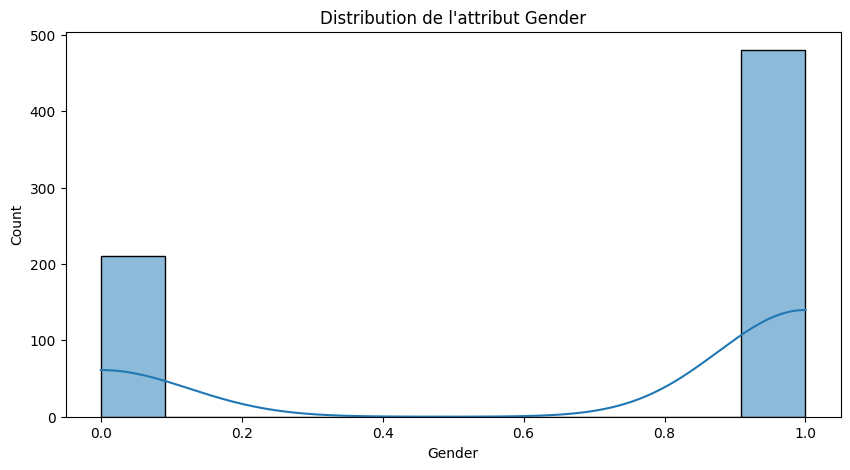

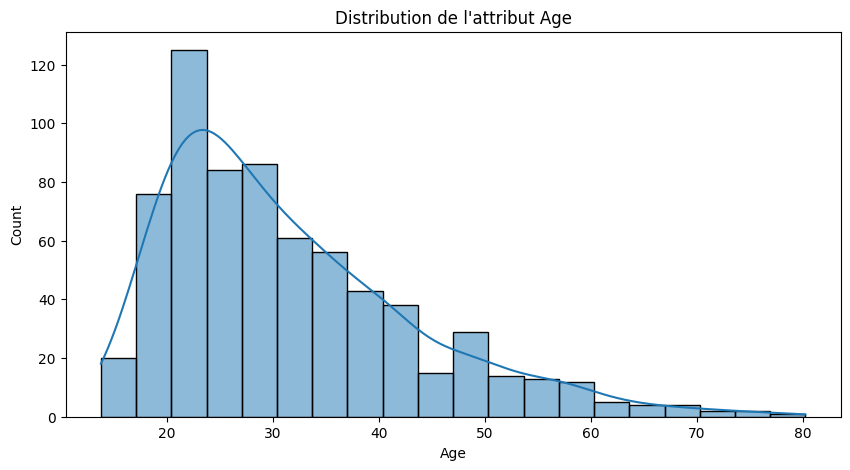

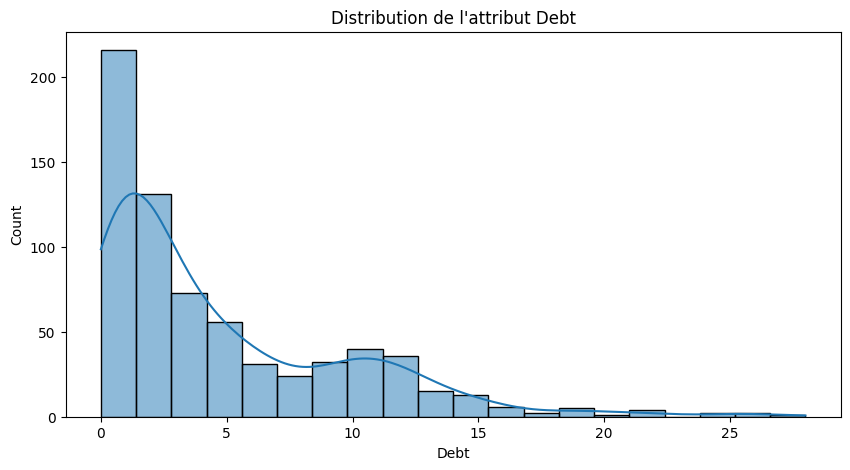

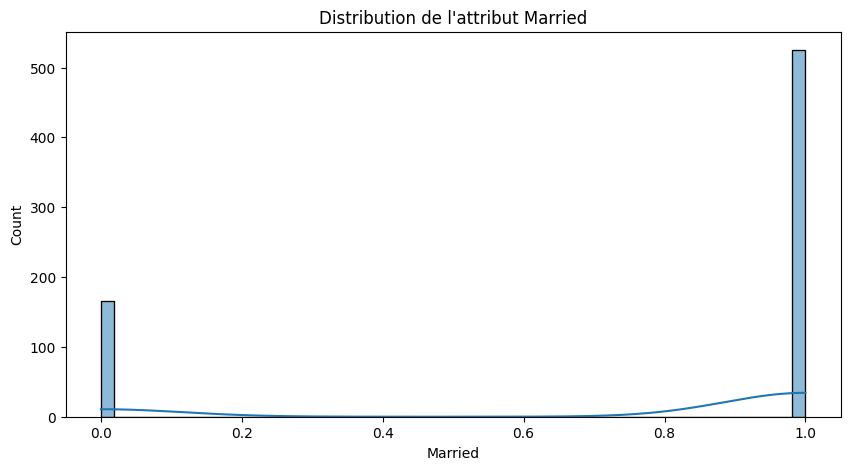

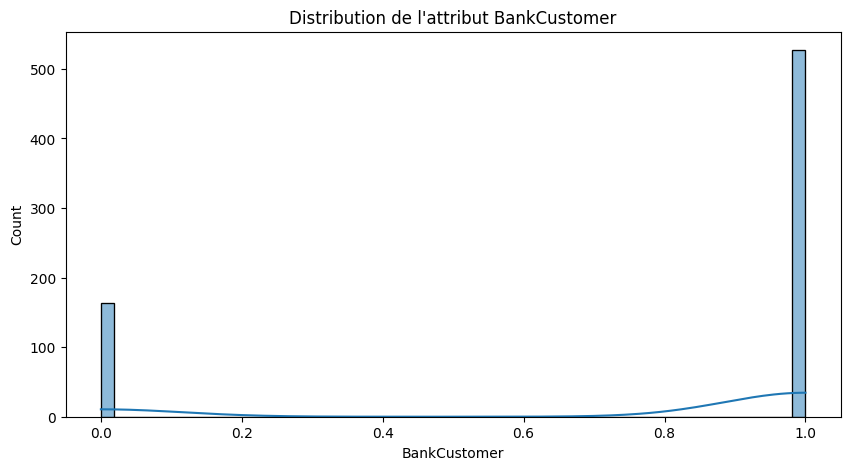

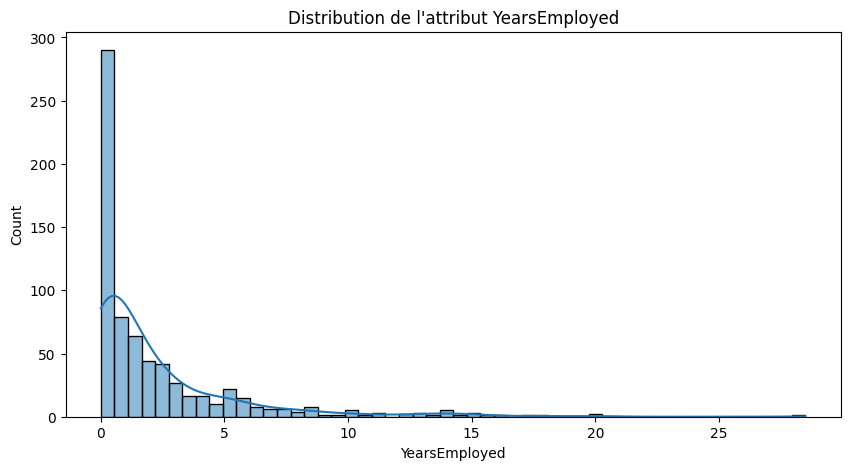

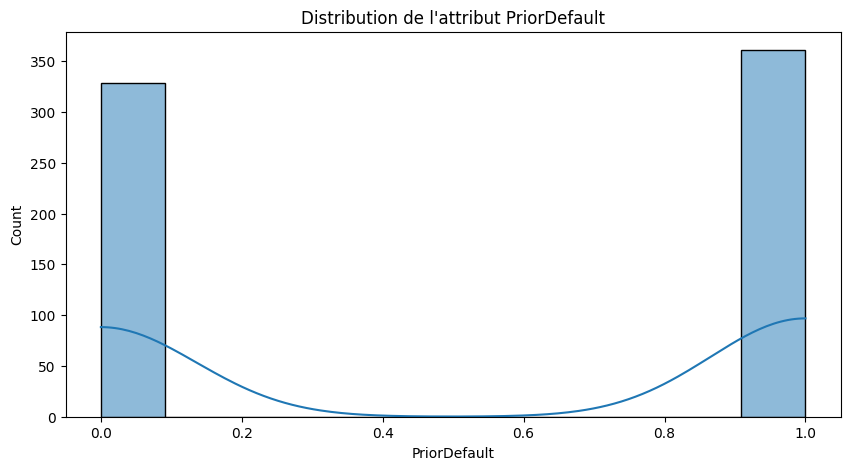

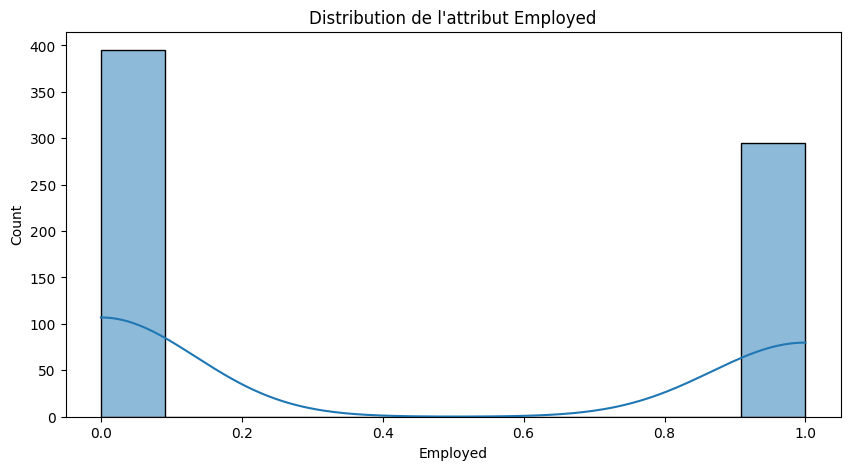

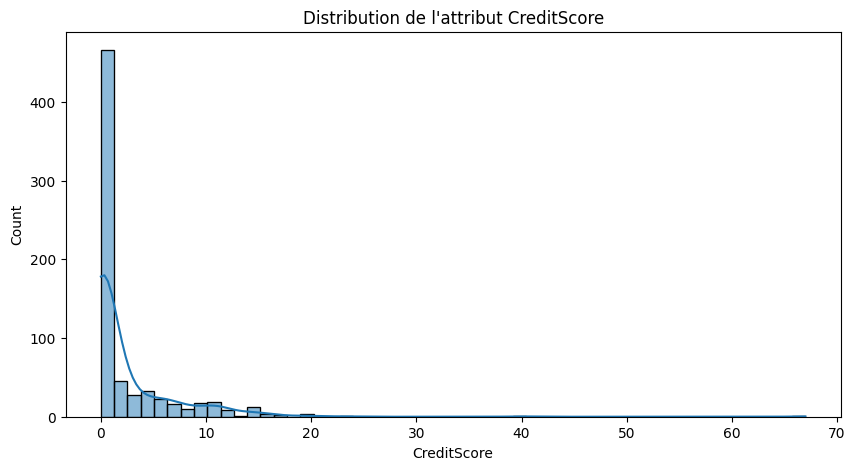

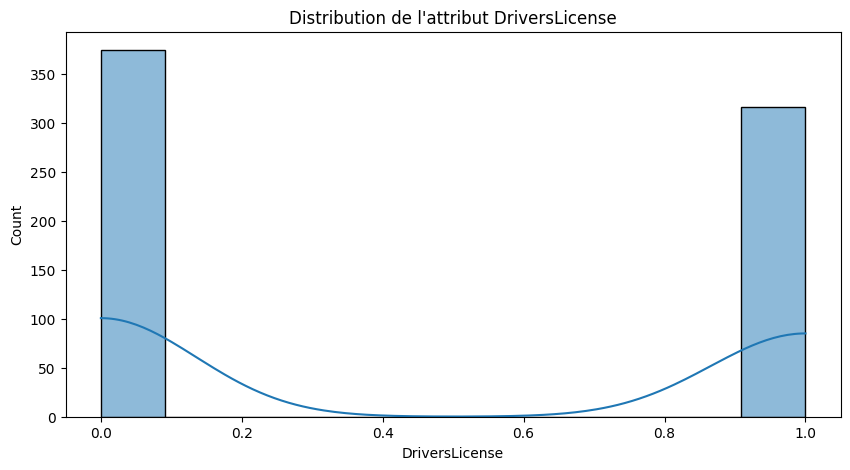

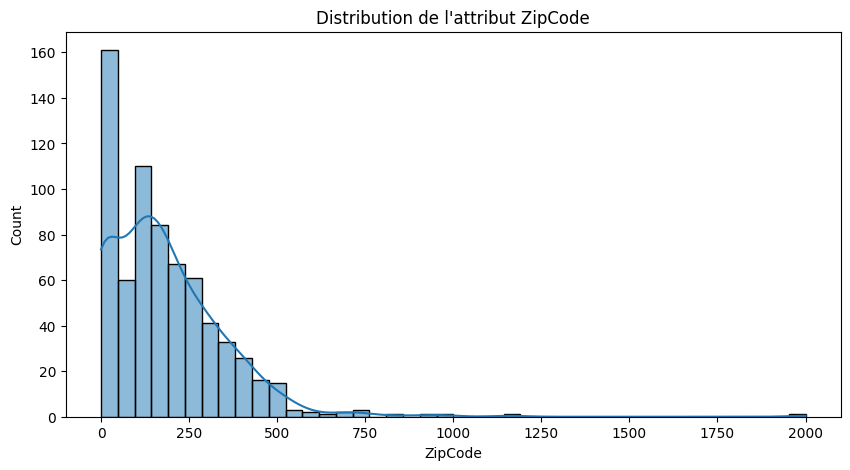

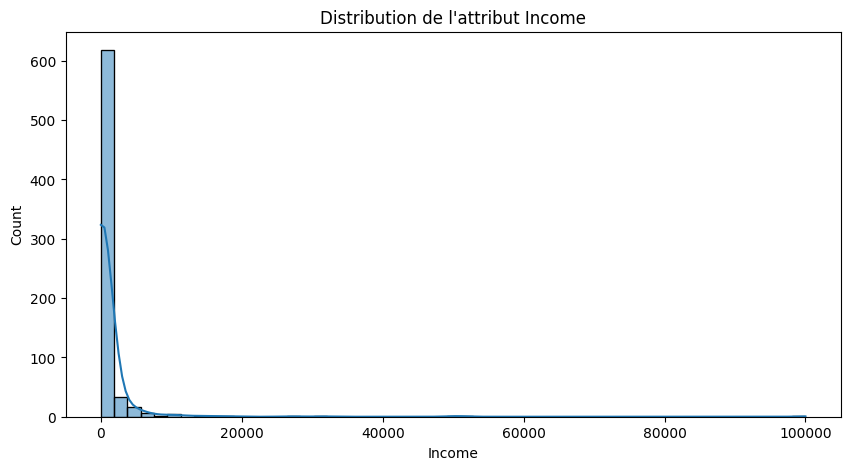

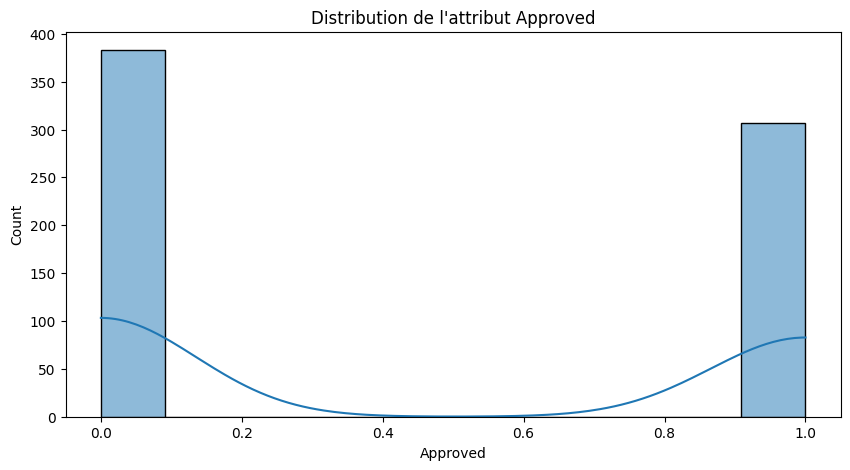

In [108]:
#Affichage de la distribution des attributs du dataset
colonne_credit_numerique = credit_df_copy.select_dtypes(include=['int64','float64']).columns

for columns in colonne_credit_numerique:
    plt.figure(figsize=(10,5))
    sns.histplot(credit_df_copy[columns], kde=True)
    plt.title(f"Distribution de l'attribut {columns}")
    plt.show()

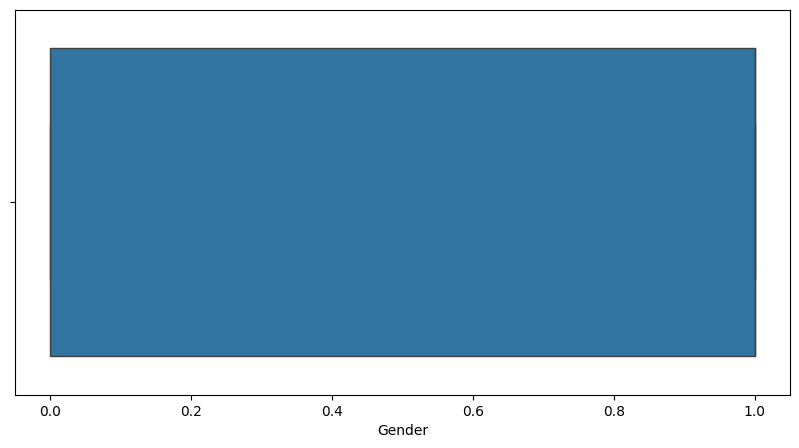

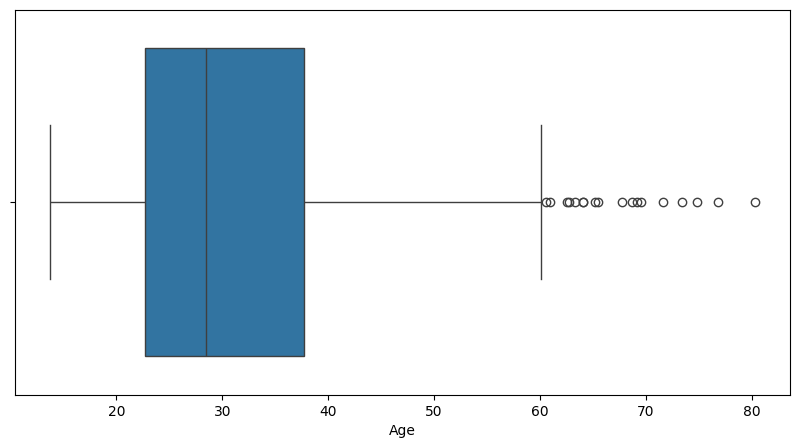

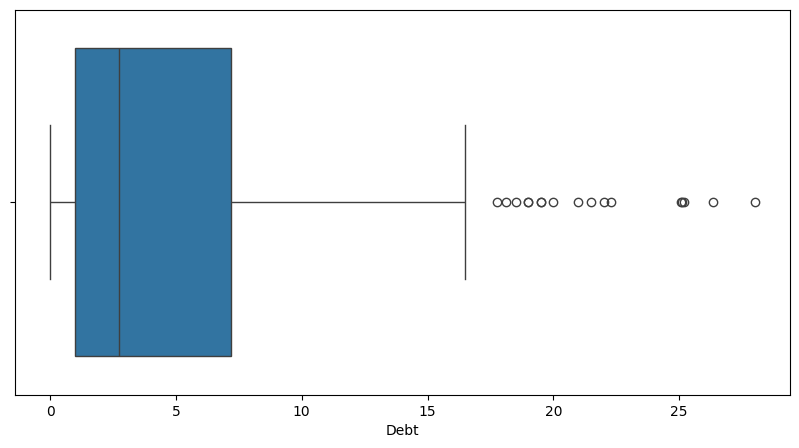

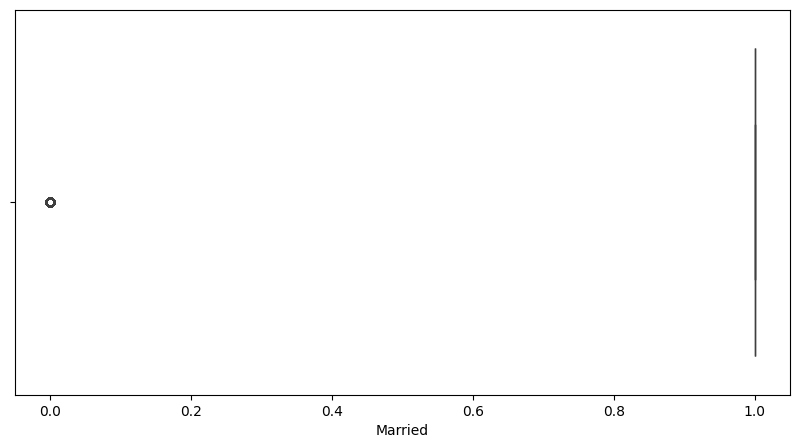

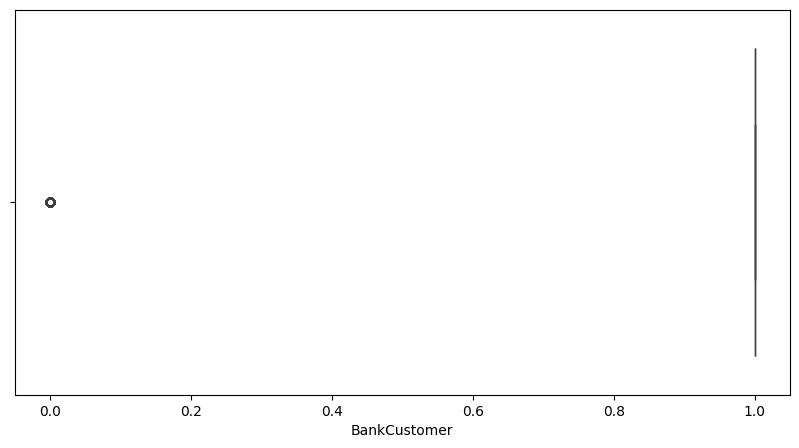

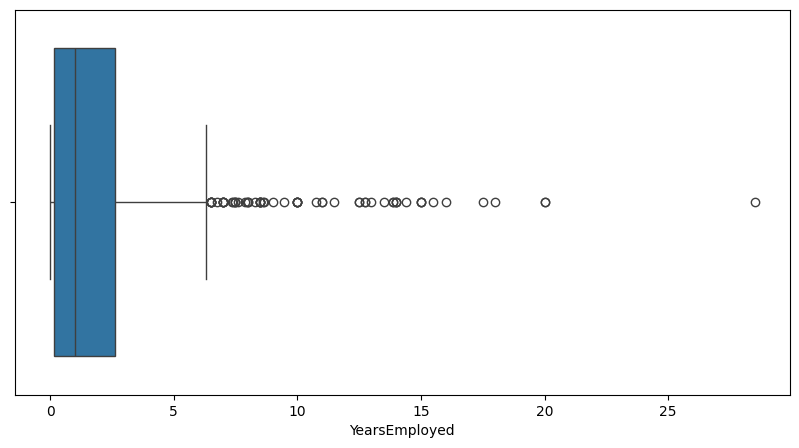

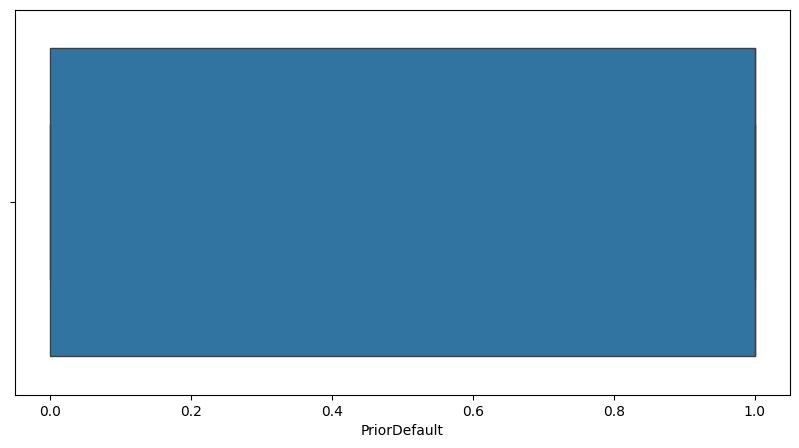

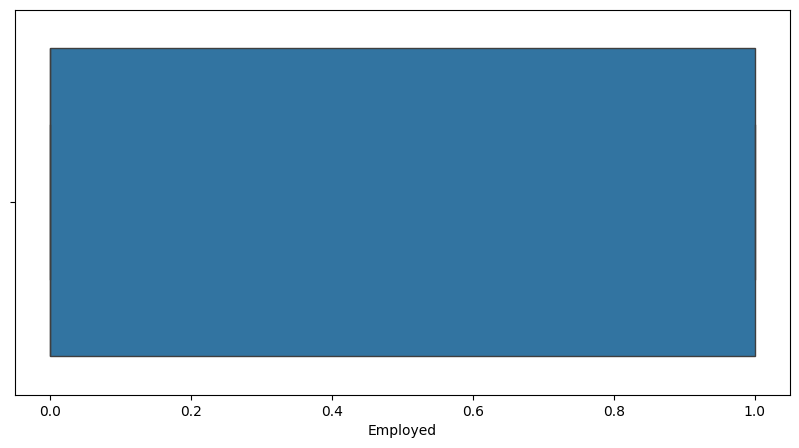

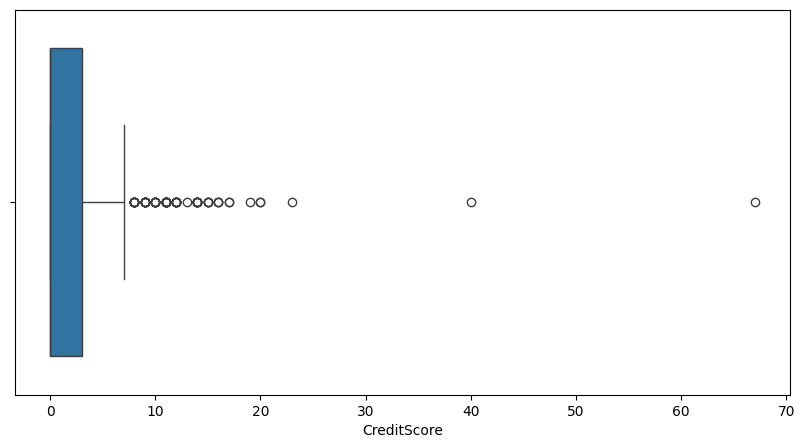

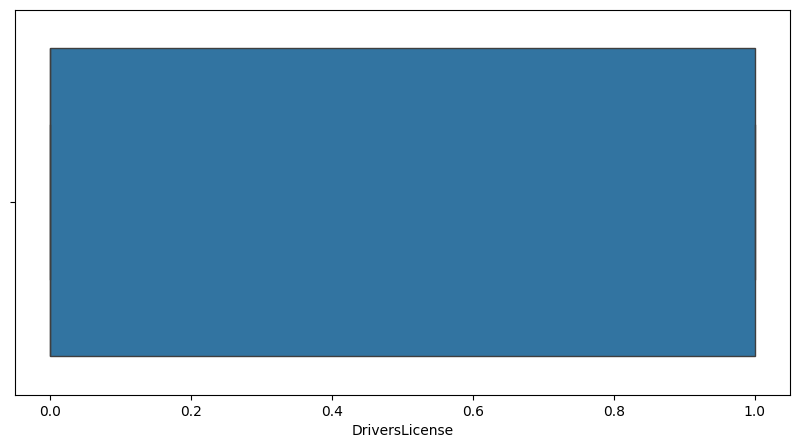

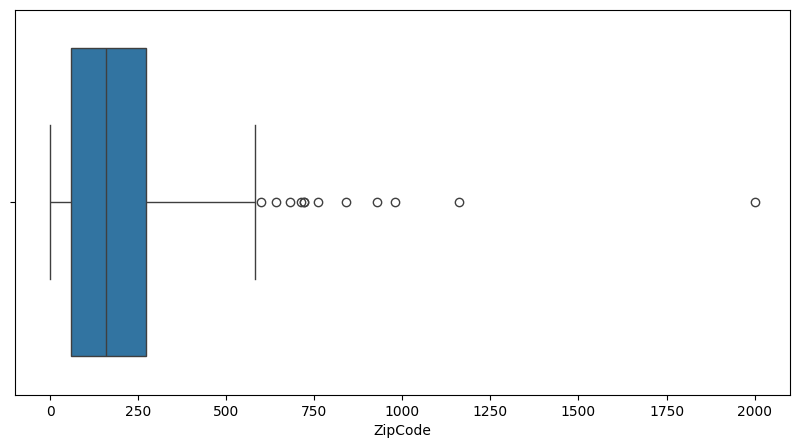

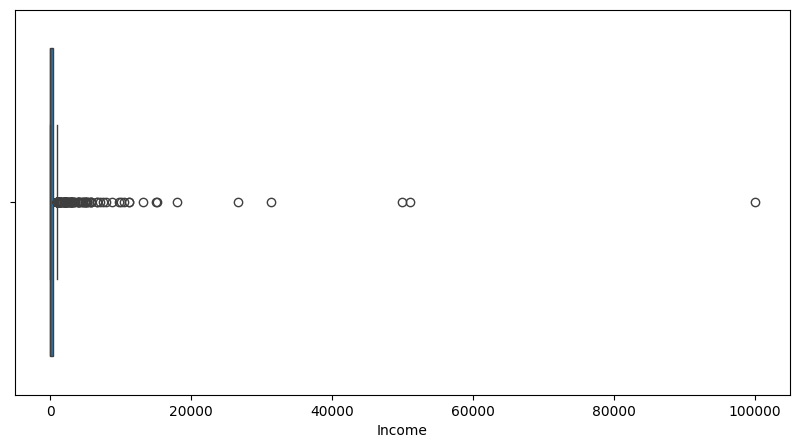

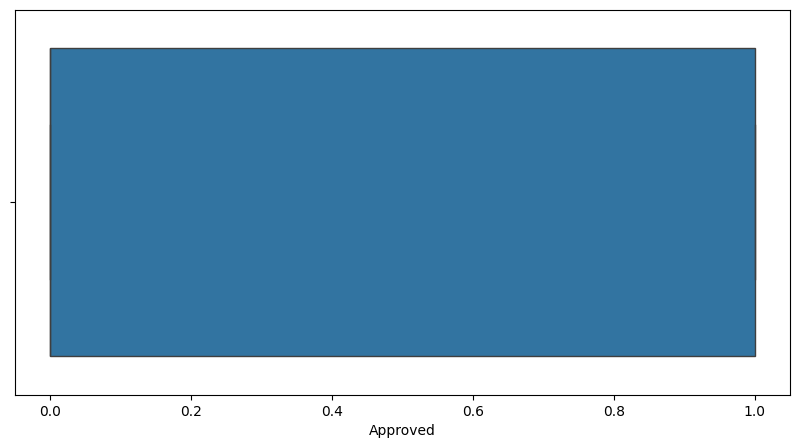

In [109]:
# affichage des valeurs abérantes
colonne_credit_numerique = credit_df_copy.select_dtypes(include=['int64','float64']).columns

for columns in colonne_credit_numerique:
    plt.figure(figsize=(10,5))
    sns.boxplot(x = credit_df_copy[columns])
    

##### Comment sont répartis les attributs catégoriels dans le dataset?

In [110]:
#print(f"Statistique descriptive des attributs non numérique\n-----------------------------------------\n{credit_df_copy[['Industry', 'Ethnicity', 'Citizen']].describe()}")
credit_df_copy[['Industry', 'Ethnicity', 'Citizen']].describe()

,Industry,Ethnicity,Citizen
count,690,690,690
unique,14,5,3
top,Energy,White,ByBirth
freq,146,408,625


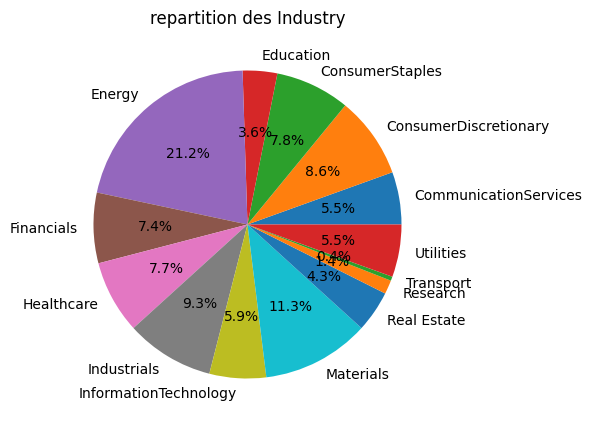

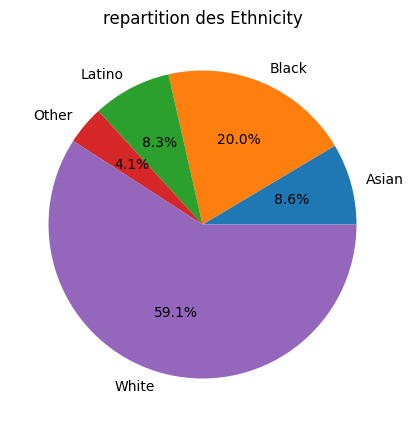

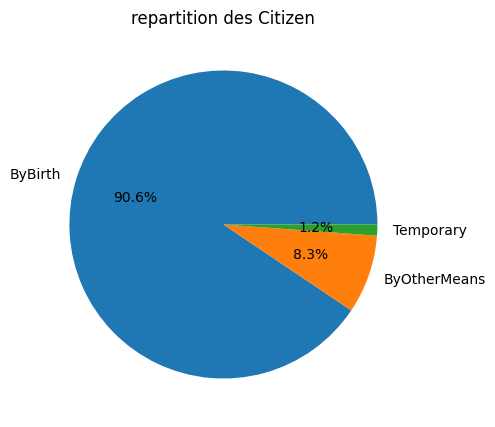

In [111]:
# Affichons les categories des attributs catégoriels
colonne_categorielle = credit_df_copy.select_dtypes(include='object').columns
for columns in colonne_categorielle:
    df_category = credit_df_copy.groupby(columns).size()
    plt.figure(figsize=(10,5))
    df_category.plot.pie(autopct='%1.1f%%', title=f"repartition des {columns}")
    plt.show()

#### Age

##### Quelle est la corrélation entre l'age et le résultat de la demande de crédit?

               Age  Approved
Age       1.000000  0.164086
Approved  0.164086  1.000000


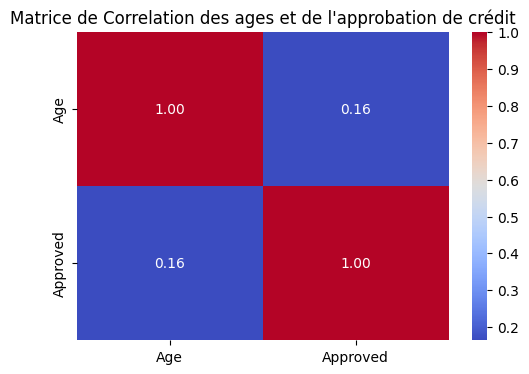

In [112]:
# Quelle est la corrélation entre l'age et l'approbation de crédit
matrice_de_correlation_age = credit_df_copy[['Age', 'Approved']]
corr_age = matrice_de_correlation_age.copy().corr()
print(corr_age)
plt.figure(figsize=(6,4))
sns.heatmap(corr_age, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Correlation des ages et de l'approbation de crédit")
plt.show()

#### Debt

##### Quelle est la corrélation entre les dettes et le résultat de la demande de crédit?

              Debt  Approved
Debt      1.000000  0.206294
Approved  0.206294  1.000000


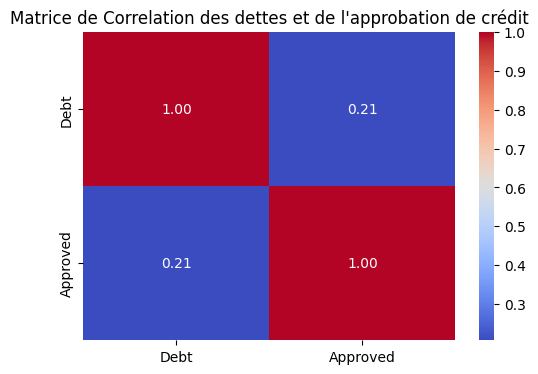

In [113]:
# Quelle est la corrélation entre les dettes et l'approbation de crédit
matrice_de_correlation_dette = credit_df_copy[['Debt', 'Approved']]
corr_debt = matrice_de_correlation_dette.copy().corr()
print(corr_debt)
plt.figure(figsize=(6,4))
sns.heatmap(corr_debt, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Correlation des dettes et de l'approbation de crédit")
plt.show()

#### YearsEmployed

##### Quelle est la corrélation entre le nombre d'années travaillé et le résultat de la demande de crédit?

               YearsEmployed  Approved
YearsEmployed       1.000000  0.322475
Approved            0.322475  1.000000


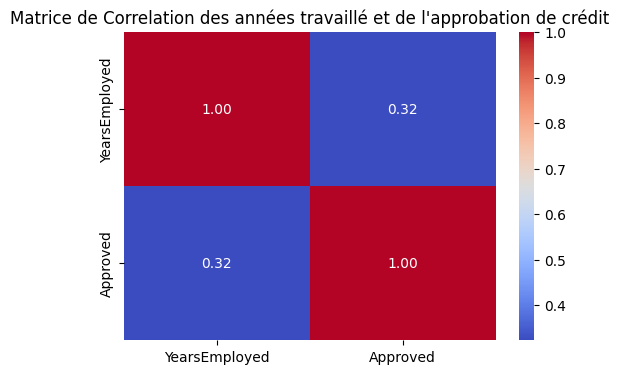

In [114]:
# Quelle est la corrélation entre les dettes et l'approbation de crédit
matrice_de_correlation_year_employed = credit_df_copy[['YearsEmployed', 'Approved']]
corr_years_employed = matrice_de_correlation_year_employed.copy().corr()
print(corr_years_employed)
plt.figure(figsize=(6,4))
sns.heatmap(corr_years_employed, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Correlation des années travaillé et de l'approbation de crédit")
plt.show()

#### ZipCode

##### Comment sont distribué les zipcode dans le dataset?

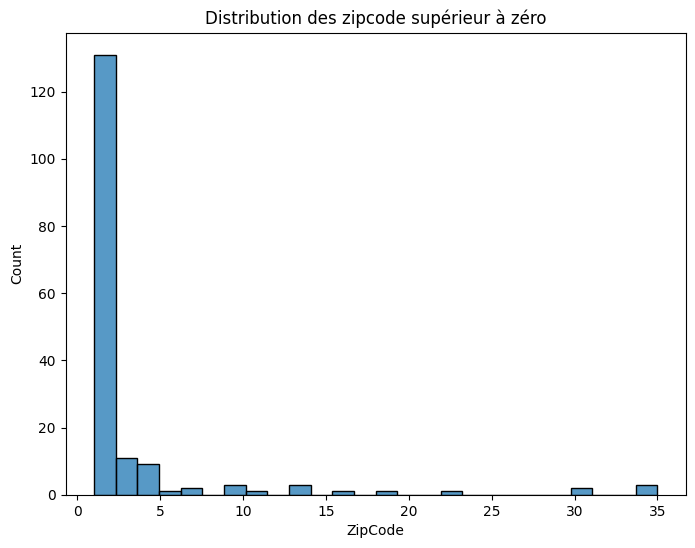

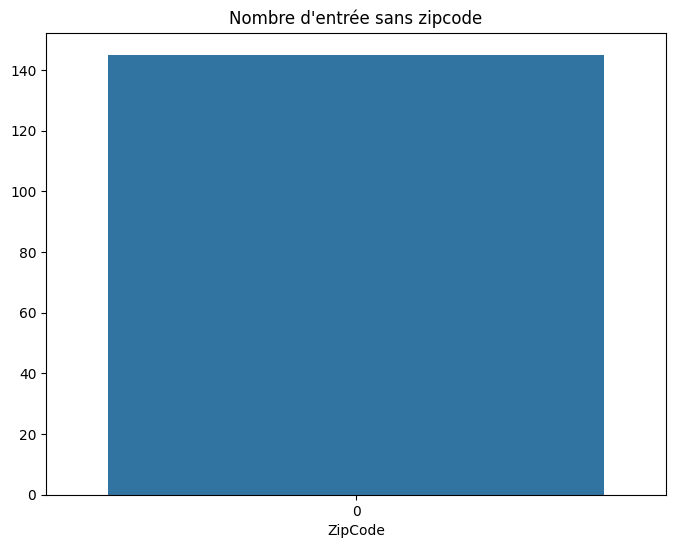

In [115]:
# On va vérifier le nombre d'entrée pareil
entry_by_zip_code_sup_zero = credit_df_copy.loc[(credit_df_copy['ZipCode'] > 0)]
entry_by_zip_code_eq_zero = credit_df_copy.loc[(credit_df_copy['ZipCode'] == 0)]
nb_person_by_zip_code_sup_zero = entry_by_zip_code_sup_zero.groupby('ZipCode').size()
plt.figure(figsize=(8,6))
sns.histplot(nb_person_by_zip_code_sup_zero)
plt.title("Distribution des zipcode supérieur à zéro")
plt.xlabel("ZipCode")
plt.show()

nb_person_by_zip_code_eq_zero = entry_by_zip_code_eq_zero.groupby('ZipCode').size()
plt.figure(figsize=(8,6))
sns.barplot(nb_person_by_zip_code_eq_zero)
plt.title("Nombre d'entrée sans zipcode")
plt.show()

In [116]:
number_zip_code_with_one_person = (credit_df_copy.groupby('ZipCode').size() == 1).sum() 
number_zip_code_not_with_one_person = (credit_df_copy.groupby('ZipCode').size() != 1).sum()
print(f"Il y a {number_zip_code_with_one_person} categorie de zipcode dans le dataset avec un seul individu ")


Il y a 104 categorie de zipcode dans le dataset avec un seul individu 


##### Quelle est la corrélation entre le zipcode et le résultat de la demande de crédit?

In [117]:
# A explorer mais on peut se poser s'il y a une reelle corelation entre le zipcode et le resultat de l'approbation. Avec si peu de donnée pour certain zipcode 1 seule par zipcode pourra t'on predire avec le zipcode?

In [118]:
# Quelle est la corrélation entre le zipcode et l'approbation
matrice_de_correlation = credit_df_copy[['ZipCode', 'Approved']]
corr = matrice_de_correlation.copy().corr()
corr

,ZipCode,Approved
ZipCode,1.000000,-0.099598
Approved,-0.099598,1.000000


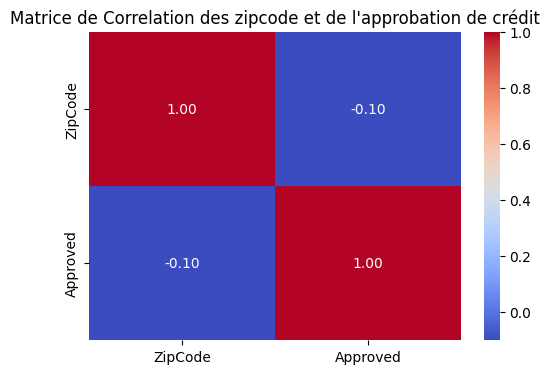

In [119]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Correlation des zipcode et de l'approbation de crédit")
plt.show()

#### Income

##### Quelle est la corrélation entre le income et le résultat de la demande de crédit?

            Income  Approved
Income    1.000000  0.175845
Approved  0.175845  1.000000


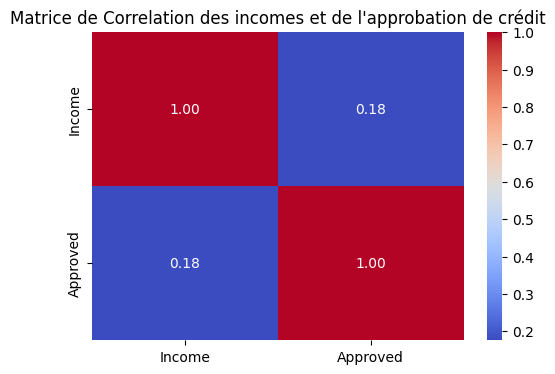

In [120]:
# Quelle est la corrélation entre le income imputé et l'approbation
matrice_de_correlation_income = credit_df_copy[['Income', 'Approved']]
corr_income = matrice_de_correlation_income.copy().corr()
print(corr_income)

plt.figure(figsize=(6,4))
sns.heatmap(corr_income, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Correlation des incomes et de l'approbation de crédit")
plt.show()

            Income  Approved
Income    1.000000  0.175657
Approved  0.175657  1.000000


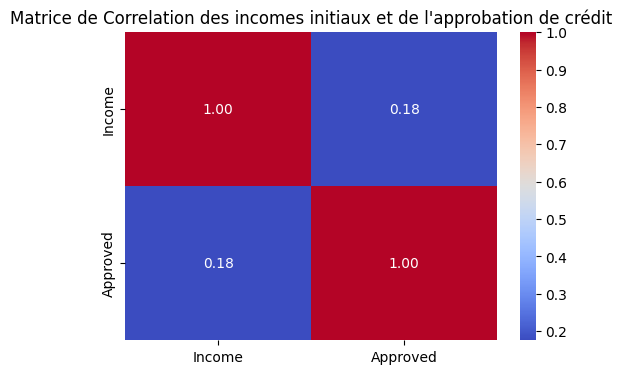

In [121]:
# Quelle est la corrélation entre le income initial et l'approbation
matrice_de_correlation_income_initial = credit_df[['Income', 'Approved']]
corr_income_initial = matrice_de_correlation_income_initial.copy().corr()
print(corr_income_initial)

plt.figure(figsize=(6,4))
sns.heatmap(corr_income_initial, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Correlation des incomes initiaux et de l'approbation de crédit")
plt.show()

In [122]:
#Au final l'attribut income n'est pas un attribut déterminant pour l'approbation de crédit

#### CreditScore

##### Comment sont distribué les valeurs de l'attribut CreditScore dans le dataset?

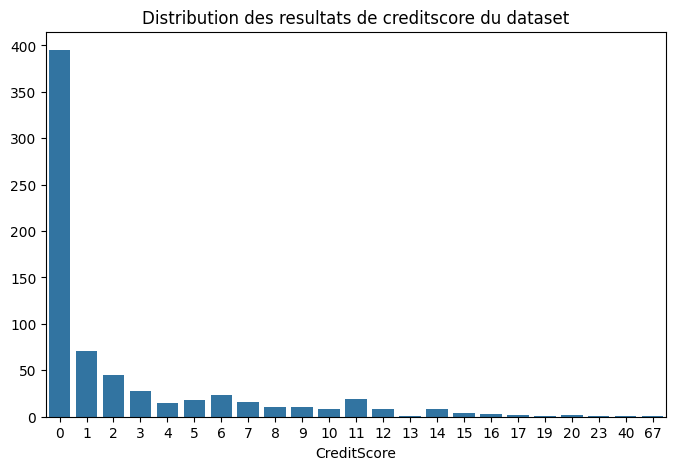

In [123]:
# Nombre d'individu par creditscore
df_distribution_credit_score = credit_df_copy.groupby('CreditScore').size()
plt.figure(figsize=(8,5))
sns.barplot(df_distribution_credit_score)
plt.title("Distribution des resultats de creditscore du dataset")
plt.show()

##### Les individus avec un creditscore supérieur au maximum de la distribution boxplot(outliers) sont ils approuvés?

In [124]:
# Analysons le outliers le plus extreme creditscore = 67
credit_df_copy.loc[credit_df_copy['CreditScore'] == 67]

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
121,1,25.67,12.5,1,1,InformationTechnology,White,1.21,1,1,67,1,ByBirth,140,258.0,1


92.0% des demandes des individus avec un haut creditscore sont acceptées


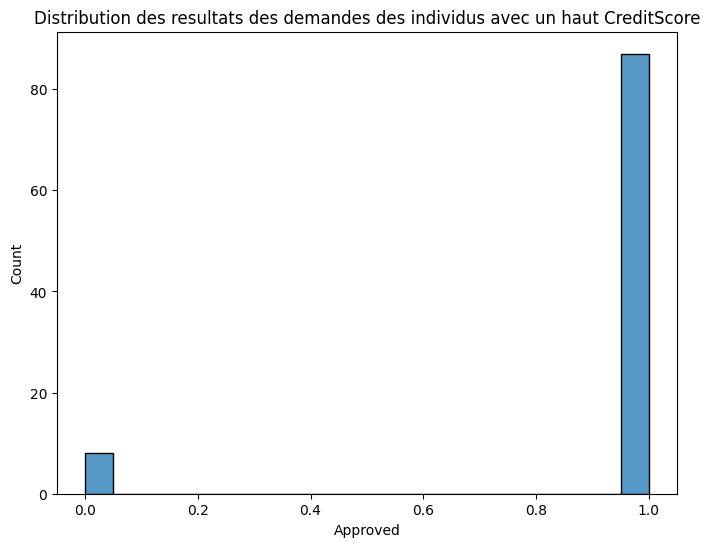

In [125]:
# Analysons les outliers supérieurs au maximum de la distribution boxplot
result_credit_score_sup_max = credit_df_copy.loc[credit_df_copy['CreditScore'] >= 7]['Approved']
moy_result_credit_score_sup_max = result_credit_score_sup_max.mean()
print(f"{moy_result_credit_score_sup_max.round(2)*100}% des demandes des individus avec un haut creditscore sont acceptées")
plt.figure(figsize=(8,6))
sns.histplot(result_credit_score_sup_max)
plt.title("Distribution des resultats des demandes des individus avec un haut CreditScore")
plt.show()

In [126]:
# Analysons les outliers supérieurs au maximum de la distribution boxplot qui sont refusé
declined_with_credit_score_sup_max = credit_df_copy.loc[(credit_df_copy['CreditScore'] >= 7) & (credit_df_copy['Approved'] == 0) ]
declined_with_credit_score_sup_max

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
105,1,54.83,15.500,1,1,Education,Other,0.000,1,1,20,0,ByBirth,152,130.0,0
116,1,37.75,7.000,1,1,Materials,Black,11.500,1,1,7,1,ByBirth,300,5.0,0
440,1,23.08,0.000,1,1,Financials,White,1.000,0,1,11,0,ByOtherMeans,0,13.0,0
463,0,36.58,0.290,1,1,Healthcare,Latino,0.000,0,1,10,0,ByBirth,200,18.0,0
482,0,17.33,9.500,1,1,ConsumerStaples,White,1.750,0,1,10,1,ByBirth,0,10.0,0
523,0,22.50,8.500,1,1,Materials,White,1.750,1,1,10,0,ByBirth,80,990.0,0
544,1,30.08,1.040,0,0,ConsumerDiscretionary,Asian,0.500,1,1,10,1,ByBirth,132,28.0,0
676,0,30.58,10.665,1,1,Materials,Black,0.085,0,1,12,1,ByBirth,129,3.0,0


In [127]:
print("Toute les entrées sont justifiable.\nNous n'avons pas d'imputation à faire à se niveau")

Toute les entrées sont justifiable.
Nous n'avons pas d'imputation à faire à se niveau


##### Quel est l'age des personnes avec un CreditScore de zéro?

Il y a 395 personne avec un creditscore de zéro


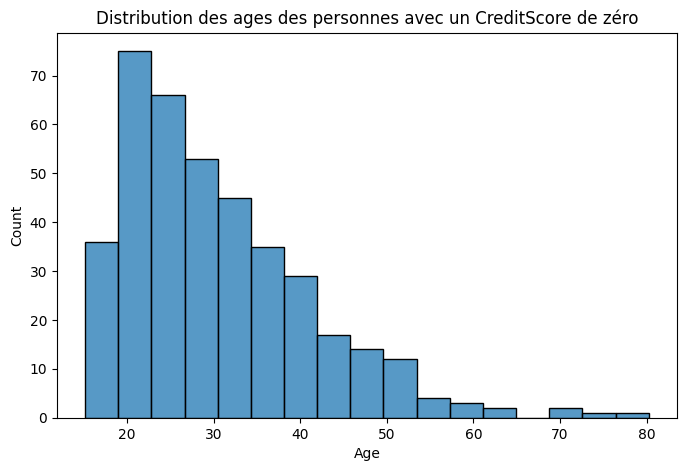

In [128]:
result_creditscore_zero = credit_df_copy.loc[(credit_df_copy['CreditScore'] == 0)]['Age']
print(f"Il y a {result_creditscore_zero.count()} personne avec un creditscore de zéro")
plt.figure(figsize=(8,5))
sns.histplot(result_creditscore_zero)
plt.title("Distribution des ages des personnes avec un CreditScore de zéro")
plt.show()

##### Quel est le resultat d'approbation des individus avec un creditscore de zéro?

Il y a 395 personne avec un creditscore de zéro


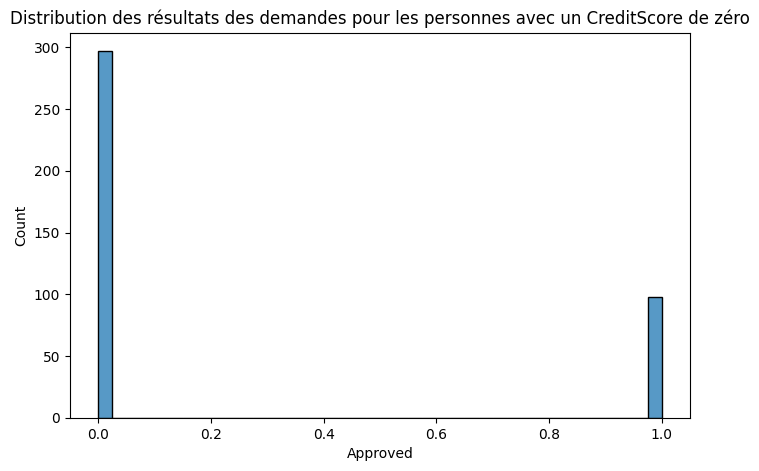

In [129]:
result_creditscore_zero = credit_df_copy.loc[(credit_df_copy['CreditScore'] == 0)]['Approved']
print(f"Il y a {result_creditscore_zero.count()} personne avec un creditscore de zéro")
plt.figure(figsize=(8,5))
sns.histplot(result_creditscore_zero)
plt.title("Distribution des résultats des demandes pour les personnes avec un CreditScore de zéro")
plt.show()

In [130]:
# Analyse des personnes avec un creditscore de zéro et une demande approuvé
positive_result_creditscore_zero = credit_df_copy.loc[(credit_df_copy['CreditScore'] == 0) & (credit_df_copy['Approved'] == 1.0)]['Approved']
index_positive_result_creditscore_zero = positive_result_creditscore_zero.index
credit_df_copy.loc[index_positive_result_creditscore_zero]

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
2,0,24.50,0.500,1,1,Materials,Black,1.500,1,0,0,0,ByBirth,280,824.0,1
4,1,20.17,5.625,1,1,Industrials,White,1.710,1,0,0,0,ByOtherMeans,120,0.0,1
5,1,32.08,4.000,1,1,CommunicationServices,White,2.500,1,0,0,1,ByBirth,360,0.0,1
6,1,33.17,1.040,1,1,Transport,Black,6.500,1,0,0,1,ByBirth,164,31285.0,1
7,0,22.92,11.585,1,1,InformationTechnology,White,0.040,1,0,0,0,ByBirth,80,1349.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,1,38.67,0.210,1,1,Financials,White,0.085,1,0,0,1,ByBirth,280,0.0,1
595,1,25.75,0.750,1,1,Energy,Asian,0.250,1,0,0,0,ByBirth,349,23.0,1
606,1,16.17,0.040,1,1,Energy,White,0.040,0,0,0,0,ByBirth,0,0.0,1
621,1,22.67,0.165,1,1,Energy,Other,2.250,0,0,0,1,ByOtherMeans,0,0.0,1


In [131]:
# Analyse des personnes avec un creditscore de zéro, une demande approuvé et n'etant pas des clients de banque
positive_result_creditscore_zero_no_bank = credit_df_copy.loc[(credit_df_copy['CreditScore'] == 0) & (credit_df_copy['Approved'] == 1.0) & (credit_df_copy['BankCustomer'] == 0)]['Approved']
index_positive_result_creditscore_zero_no_bank = positive_result_creditscore_zero_no_bank.index
credit_df_copy.loc[index_positive_result_creditscore_zero_no_bank]

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
8,1,54.42,0.500,0,0,Financials,Black,3.960,1,0,0,0,ByBirth,180,314.0,1
9,1,42.50,4.915,0,0,Industrials,White,3.165,1,0,0,1,ByBirth,52,1442.0,1
55,1,23.33,11.625,0,0,Industrials,White,0.835,1,0,0,1,ByBirth,160,300.0,1
163,1,32.00,1.750,0,0,Education,Black,0.040,1,0,0,1,ByBirth,393,0.0,1
169,1,37.50,1.125,0,0,Real Estate,White,1.500,0,0,0,1,ByBirth,431,0.0,1
170,0,25.08,2.540,0,0,ConsumerStaples,White,0.250,1,0,0,1,ByBirth,370,0.0,1
175,1,27.00,1.500,0,0,Industrials,White,0.375,1,0,0,1,ByBirth,260,1065.0,1
211,1,24.33,6.625,0,0,Real Estate,White,5.500,1,0,0,1,ByOtherMeans,100,0.0,1
227,0,22.50,8.460,0,0,Utilities,White,2.460,0,0,0,0,ByBirth,164,0.0,1
240,1,20.50,10.000,0,0,Energy,White,2.500,1,0,0,0,ByOtherMeans,40,0.0,1


In [132]:
# Analyse des personnes avec un creditscore de zéro, une demande approuvé et sans années d'emploi 
positive_result_creditscore_zero_no_y_employed = credit_df_copy.loc[(credit_df_copy['CreditScore'] == 0) & (credit_df_copy['Approved'] == 1.0) & (credit_df_copy['YearsEmployed'] == 0)]['Approved']
index_positive_result_creditscore_zero_no_y_employed = positive_result_creditscore_zero_no_y_employed.index
credit_df_copy.loc[index_positive_result_creditscore_zero_no_y_employed]

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
53,1,34.92,2.50,1,1,Industrials,White,0.0,1,0,0,1,ByBirth,239,200.0,1
206,0,71.58,0.00,1,1,Energy,White,0.0,0,0,0,0,Temporary,0,0.0,1
236,1,26.17,0.25,1,1,ConsumerDiscretionary,Asian,0.0,1,0,0,1,ByBirth,0,0.0,1
270,1,37.58,0.00,1,1,Energy,White,0.0,0,0,0,0,Temporary,0,0.0,1
317,1,17.50,22.00,0,1,Healthcare,Other,0.0,0,0,0,1,Temporary,450,100000.0,1
318,1,19.17,0.00,0,0,CommunicationServices,Asian,0.0,0,0,0,1,ByOtherMeans,500,1.0,1
511,0,46.00,4.00,1,1,Research,Other,0.0,1,0,0,0,ByBirth,100,960.0,1
513,1,20.25,9.96,1,1,Education,Other,0.0,1,0,0,0,ByBirth,0,0.0,1
584,0,28.08,15.00,0,0,Education,Other,0.0,1,0,0,0,ByBirth,0,13212.0,1
585,1,73.42,17.75,1,1,Healthcare,Latino,0.0,1,0,0,1,ByBirth,0,0.0,1


In [133]:
print("Il n'y a aucune valeur abérantes lors de l'analyse des valeurs de creditscore. En general un creditscore de zéro est un refus.\nToutefois, si approuvé, d'autre facteur peuvent l'expliquer")

Il n'y a aucune valeur abérantes lors de l'analyse des valeurs de creditscore. En general un creditscore de zéro est un refus.
Toutefois, si approuvé, d'autre facteur peuvent l'expliquer


##### Quelle est la corrélation entre le CreditScore et le résultat de la demande de crédit?

In [134]:
# Quelle est la corrélation entre le CreditScore et l'approbation
matrice_de_correlation_creditscore = credit_df_copy[['CreditScore', 'Approved']]
corr_credit_score = matrice_de_correlation_creditscore.copy().corr()
corr_credit_score

,CreditScore,Approved
CreditScore,1.00000,0.40641
Approved,0.40641,1.00000


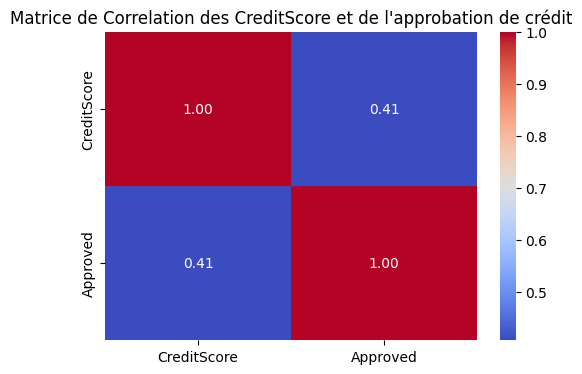

In [135]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_credit_score, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Correlation des CreditScore et de l'approbation de crédit")
plt.show()

## Équilibrage des classes Credit

#### Séparation du dataset pour les données d'apprentissage

In [136]:
#Separation du dataset X et Y(Input/Output)
X_credit = credit_df_final.iloc[:,: -1]
Y_credit = credit_df_final.iloc[:, -1]

#Séparation en 70 % train / 30 % test
X_train_credit, X_test_credit, Y_train_credit, Y_test_credit = train_test_split(X_credit, Y_credit, test_size=0.3, random_state=42)

#### Diagnostique du déséquilibre

In [137]:
#Diagnostique du déséquilibre avant équilibrage
print("Diagnostique du déséquilibre de la cible à prédire avant équilibrage\n--------------------------------------------------------------------\n")
counts_before = Y_train_credit.value_counts()
ratio_before = counts_before.min()/counts_before.max()
print(counts_before)
print(f"\nLe ratio de déséquilibre de la classe minoritaire est {ratio_before:.2f}")
 

Diagnostique du déséquilibre de la cible à prédire avant équilibrage
--------------------------------------------------------------------

Approved
0    273
1    210
Name: count, dtype: int64

Le ratio de déséquilibre de la classe minoritaire est 0.77


In [138]:
#Sélection de la classe minoritaire et séparation du dataset X et Y(Input/Output)
X_credit_classe_minoritaire = credit_df_final.loc[credit_df_final['Approved'] == 1].iloc[:,: -1]
Y_credit_classe_minoritaire = credit_df_final.loc[credit_df_final['Approved'] == 1].iloc[:, -1]

#### Équilibrage classe avec SMOTE

In [139]:
#Definition de la fonction de réquilibrage smote
categorical_features = list(range(6,20)) + list(range(20,25)) + list(range(30,32))
smote = SMOTENC(categorical_features, random_state=42)

#Application de la fonction de reéquilibrage
X_smote_credit, Y_smote_credit = smote.fit_resample(X_train_credit, Y_train_credit)
counts_after_smote = Y_smote_credit.value_counts()
ratio_after_smote = counts_after_smote.min()/counts_after_smote.max()

#Diagnostique du déséquilibre Avant/Après équilibrage
print("Diagnostique du déséquilibre de la cible à prédire après équilibrage avec SMOTE\n--------------------------------------------------------------------\n")
print(counts_after_smote)
print(f"\nLe ratio de déséquilibre de la classe minoritaire après équilibrage est maintenant {ratio_after_smote:.2f}")


Diagnostique du déséquilibre de la cible à prédire après équilibrage avec SMOTE
--------------------------------------------------------------------

Approved
1    273
0    273
Name: count, dtype: int64

Le ratio de déséquilibre de la classe minoritaire après équilibrage est maintenant 1.00


##### Observations des attributs avec le plus de outliers après équilibrage avec SMOTE

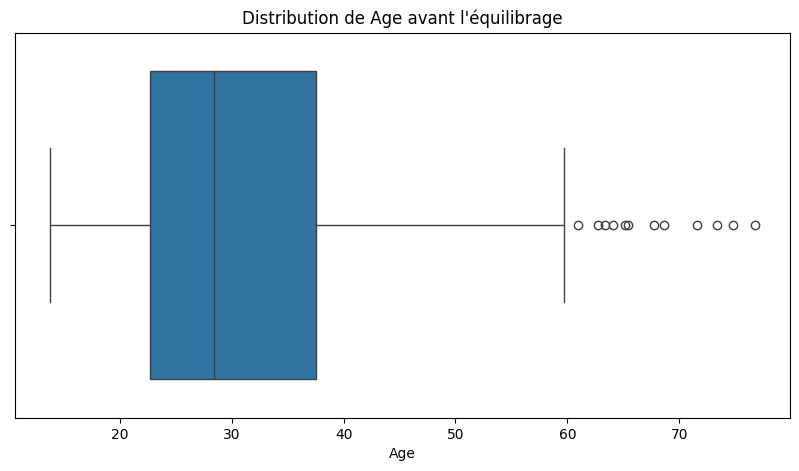

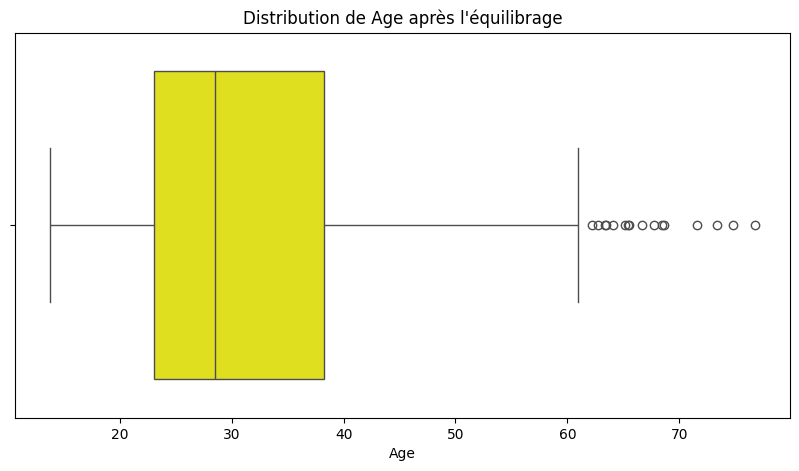

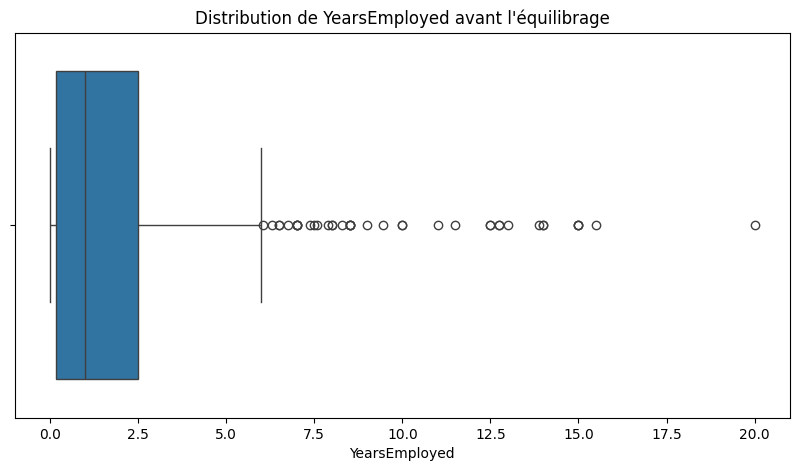

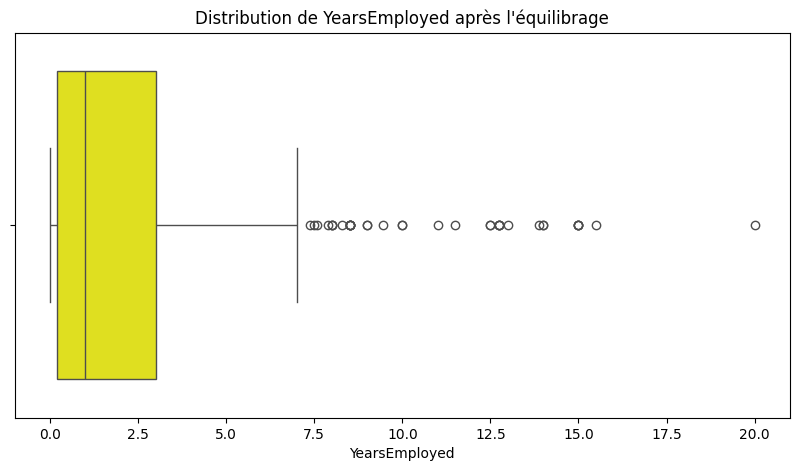

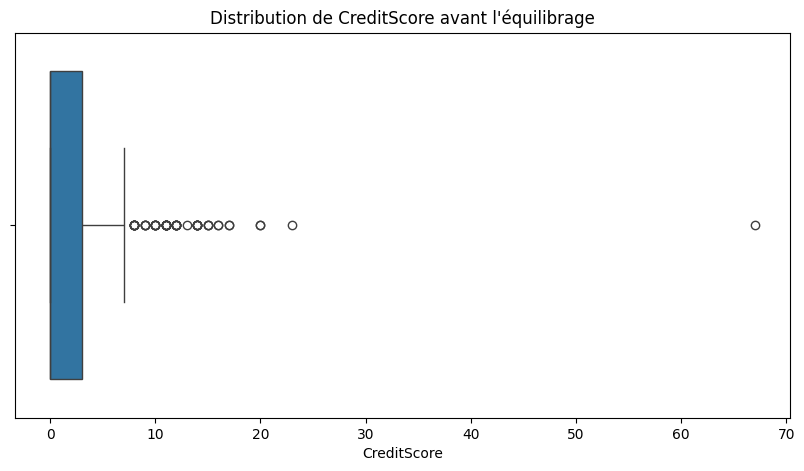

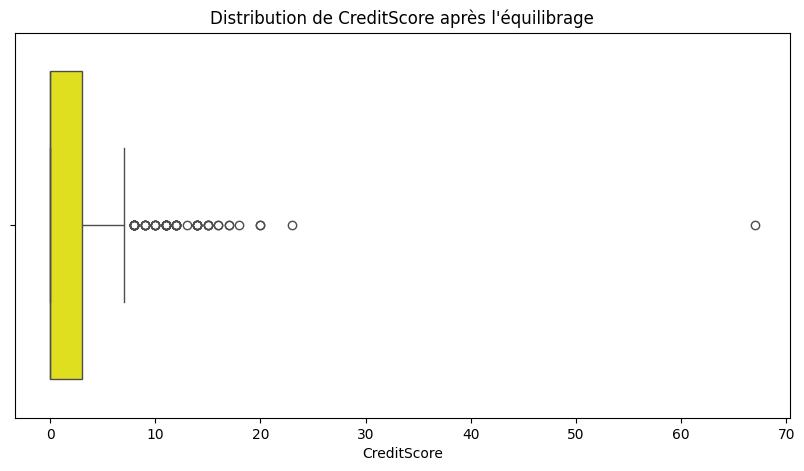

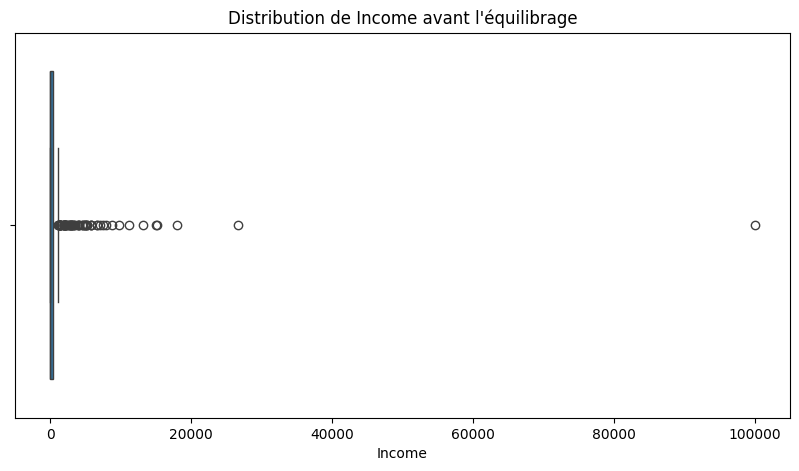

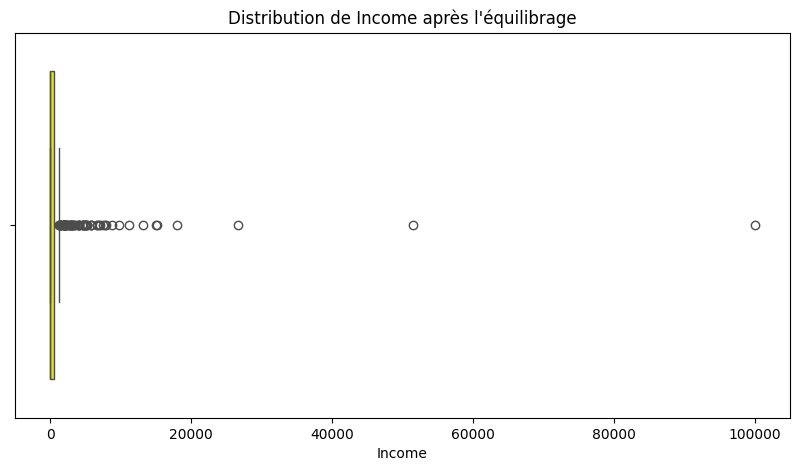

In [140]:
# On veut observer age, debt, yearsEmployed, creditScore, Income
colonne_credit_numerique_after = X_smote_credit.loc[:, ['Age', 'YearsEmployed', 'CreditScore', 'Income']]
colonne_credit_numerique_before = X_train_credit.loc[:, ['Age', 'YearsEmployed', 'CreditScore', 'Income']]

for columns in colonne_credit_numerique_after:
    plt.figure(figsize=(10,5))
    sns.boxplot(x = X_train_credit[columns])
    plt.title(f"Distribution de {columns} avant l'équilibrage")
    plt.show()
    plt.figure(figsize=(10,5))
    sns.boxplot(x = X_smote_credit[columns], color='yellow')
    plt.title(f"Distribution de {columns} après l'équilibrage")
    plt.show()

#### Équilibrage des classes avec RandomOverSampler

In [141]:
#On va utiliser un overSampler car notre échantillon de données n'est pas grand

#Definition de la fonction de réquilibrage RandomOverSampler
ros = RandomOverSampler(random_state=42)

#Application de la fonction de reéquilibrage
X_ros_credit, Y_ros_credit = ros.fit_resample(X_train_credit, Y_train_credit)
counts_after_ros = Y_ros_credit.value_counts()
ratio_after_ros = counts_after_ros.min()/counts_after_ros.max()

#Diagnostique du déséquilibre Avant/Après équilibrage
print("Diagnostique du déséquilibre de la cible à prédire après équilibrage avec RandomOverSampler\n--------------------------------------------------------------------\n")
print(counts_after_ros)
print(f"\nLe ratio de déséquilibre de la classe minoritaire après équilibrage est maintenant {ratio_after_ros:.2f}")

Diagnostique du déséquilibre de la cible à prédire après équilibrage avec RandomOverSampler
--------------------------------------------------------------------

Approved
1    273
0    273
Name: count, dtype: int64

Le ratio de déséquilibre de la classe minoritaire après équilibrage est maintenant 1.00


##### Observations des attributs avec le plus de outliers après équilibrage avec RandomOverSampler

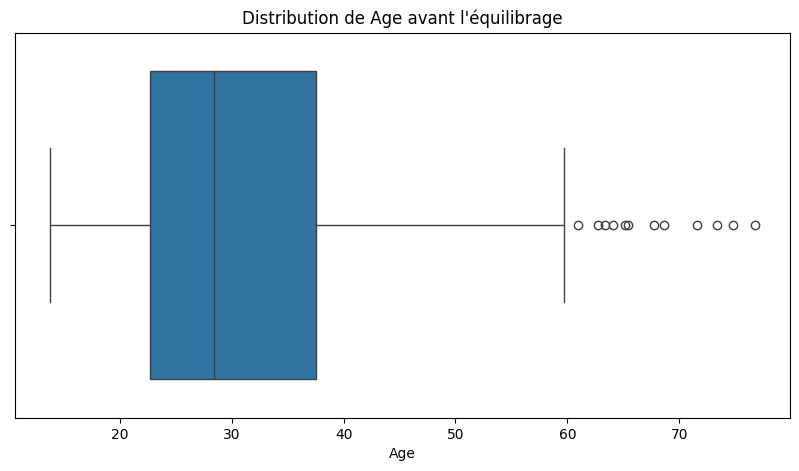

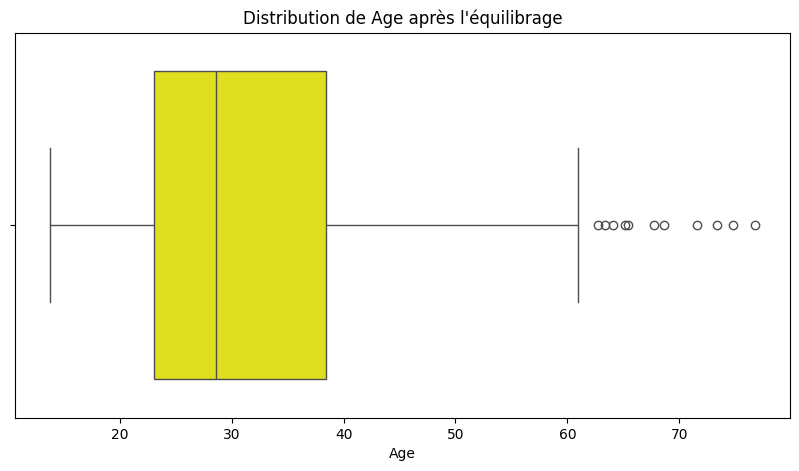

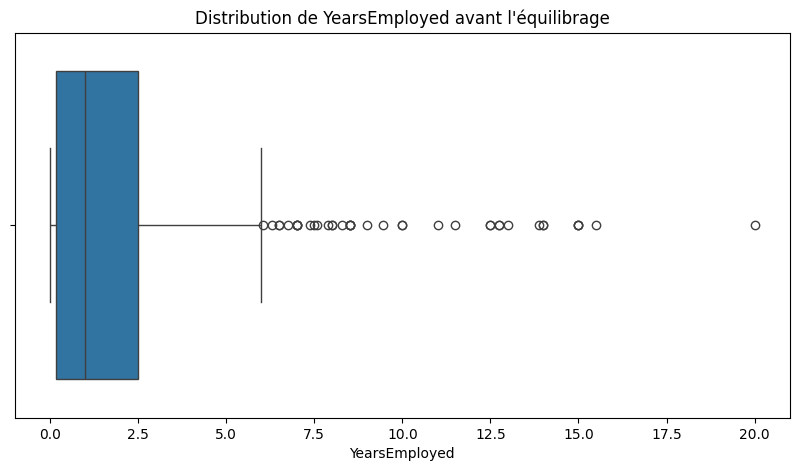

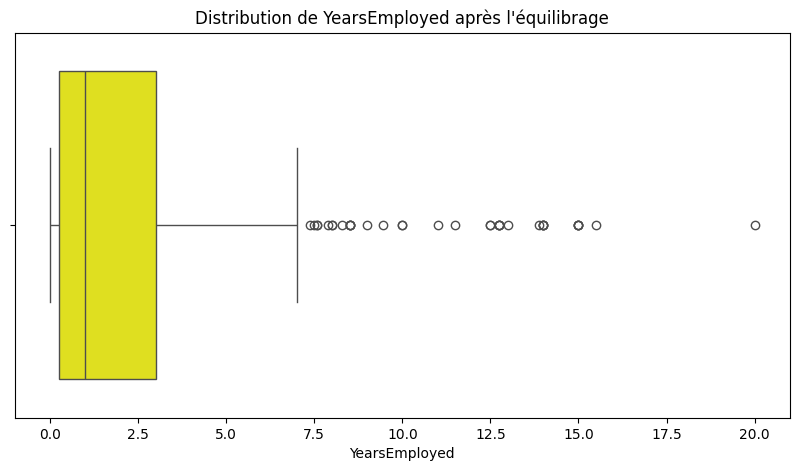

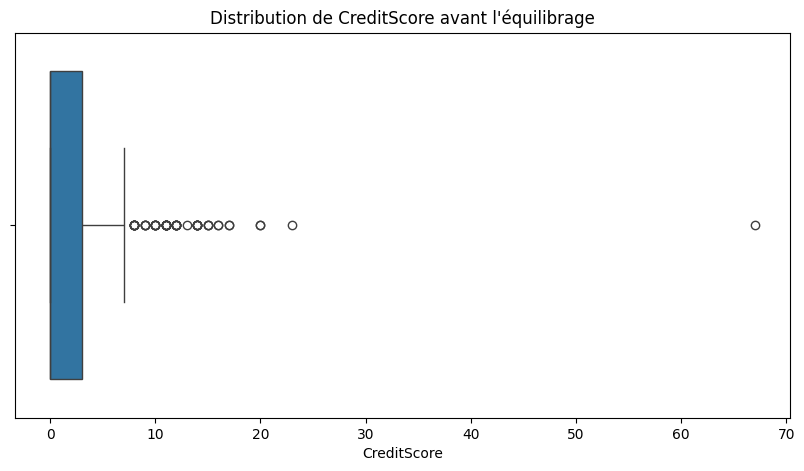

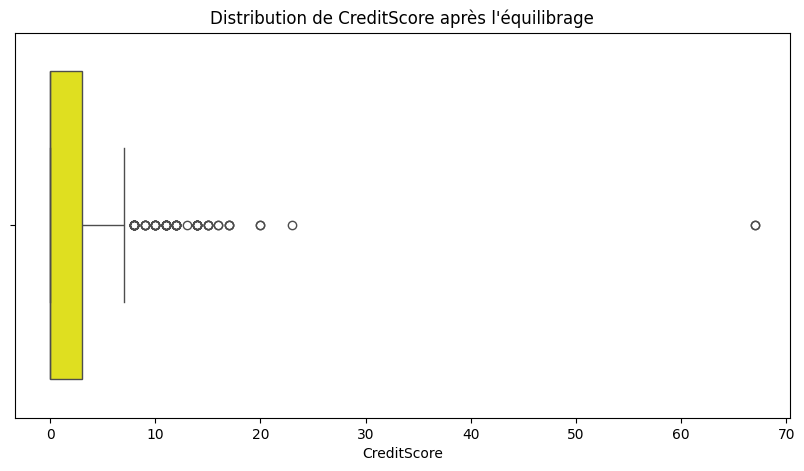

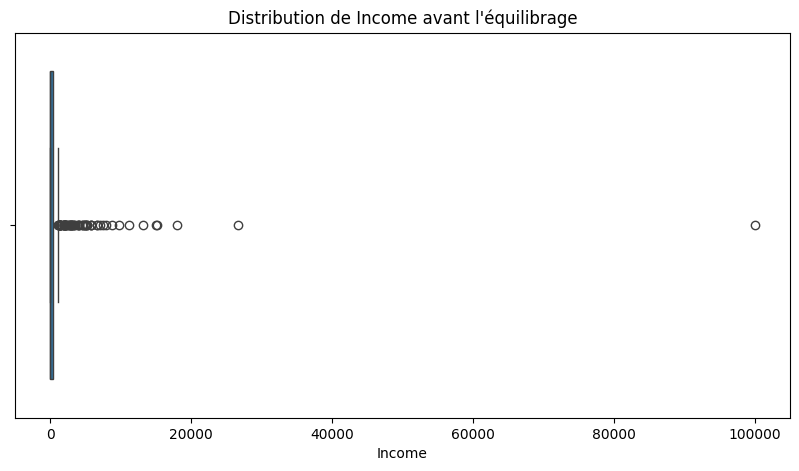

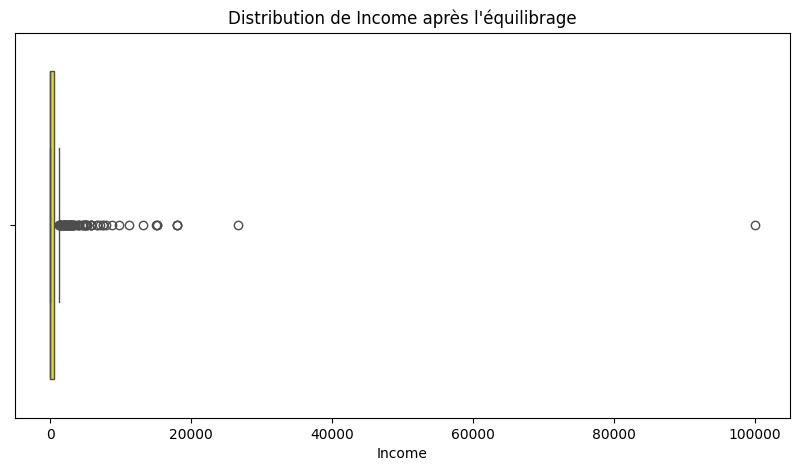

In [142]:
# On veut observer age, debt, yearsEmployed, creditScore, Income
colonne_credit_numerique_after_ros = X_ros_credit.loc[:, ['Age', 'YearsEmployed', 'CreditScore', 'Income']]
colonne_credit_numerique_before = X_train_credit.loc[:, ['Age', 'YearsEmployed', 'CreditScore', 'Income']]

for columns in colonne_credit_numerique_after_ros:
    plt.figure(figsize=(10,5))
    sns.boxplot(x = X_train_credit[columns])
    plt.title(f"Distribution de {columns} avant l'équilibrage")
    plt.show()
    plt.figure(figsize=(10,5))
    sns.boxplot(x = X_ros_credit[columns], color='yellow')
    plt.title(f"Distribution de {columns} après l'équilibrage")
    plt.show()

#### Analyse de l'équilibrage

In [143]:
# Description de la distribution des attributs avant l'équilibrage
X_train_credit.loc[:, ['Age','YearsEmployed','CreditScore', 'Income']].describe()

,Age,YearsEmployed,CreditScore,Income
count,483.000000,483.000000,483.000000,483.000000
mean,31.433333,2.022878,2.451346,974.084886
std,11.822101,2.961988,5.001578,5069.442802
min,13.750000,0.000000,0.000000,0.000000
25%,22.710000,0.165000,0.000000,0.000000
50%,28.420000,1.000000,0.000000,13.000000
75%,37.500000,2.500000,3.000000,428.000000
max,76.750000,20.000000,67.000000,100000.000000


In [144]:
# Description de la distribution des attributs après l'équilibrage avec SMOTE
X_smote_credit.loc[:, ['Age','YearsEmployed','CreditScore', 'Income']].describe()

,Age,YearsEmployed,CreditScore,Income
count,546.000000,546.000000,546.000000,546.000000
mean,31.909848,2.195998,2.576923,1043.473894
std,11.968100,3.038800,4.910814,5264.058214
min,13.750000,0.000000,0.000000,0.000000
25%,23.000000,0.210000,0.000000,0.000000
50%,28.500000,1.000000,0.000000,13.000000
75%,38.250000,3.000000,3.000000,500.000000
max,76.750000,20.000000,67.000000,100000.000000


In [145]:
# Description de la distribution des attributs après l'équilibrage avec RandomOverSampler
X_ros_credit.loc[:, ['Age','YearsEmployed','CreditScore', 'Income']].describe()

,Age,YearsEmployed,CreditScore,Income
count,546.000000,546.000000,546.000000,546.000000
mean,31.866795,2.181960,2.743590,1052.783883
std,11.823843,3.058274,5.679208,4939.849287
min,13.750000,0.000000,0.000000,0.000000
25%,23.000000,0.250000,0.000000,0.000000
50%,28.580000,1.000000,0.000000,13.000000
75%,38.397500,3.000000,3.000000,500.000000
max,76.750000,20.000000,67.000000,100000.000000


## Modélisation supervisée Credit

#### Apprentissage supervisé

In [146]:
# On cree une liste de modeles en tuples
models = []
models.append(('LR', LogisticRegression(solver='newton-cg')))
models.append(('DT', DecisionTreeClassifier()))
models.append(('RF', RandomForestClassifier()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVM', SVC(probability=True)))
models.append(('NB', GaussianNB()))
models.append(('GB', GradientBoostingClassifier()))

# On cree une liste de metriques en tuples
metrics = []
metrics.append(('Accuracy', accuracy_score))
metrics.append(('Precision', precision_score))
metrics.append(('Recall', recall_score))
metrics.append(('F1-score', f1_score))
metrics.append(('AUC-ROC', roc_auc_score))

#Création d'un tableau comparatif des scores par modèle et par méthode de validation
df_comparaison_credit = pd.DataFrame(columns=['modele', 'metrique', 'methode-de-validation', 'score', 'score-train'])


In [147]:
#Verification des scores par modèle et par métrique
for models_name, model in models:
    model.fit(X_ros_credit,Y_ros_credit)
    Y_prediction_credit = (model.predict_proba(X_test_credit)[:,1] >= 0.5).astype(int)
    Y_train_prediction_credit = (model.predict_proba(X_ros_credit)[:,1] >= 0.5).astype(int)
    for metrics_name, metric in metrics:
        comparaison_modele_credit_ajout = pd.DataFrame({'modele': [models_name], 'metrique': [metrics_name], 'methode-de-validation': ['70 % train / 30 % test'], 'score': [metric(Y_test_credit.values,Y_prediction_credit)*100], 'score-train': [metric(Y_ros_credit,Y_train_prediction_credit)*100]})
        df_comparaison_credit = pd.concat([df_comparaison_credit,comparaison_modele_credit_ajout], ignore_index=True)
        
    

/var/folders/1g/cphp03qd215btnhr3lkgl4qw0000gn/T/ipykernel_69038/807156272.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comparaison_credit = pd.concat([df_comparaison_credit,comparaison_modele_credit_ajout], ignore_index=True)


#### Validation croisée

In [148]:
# metriques
scoring = {
    'accuracy'  : make_scorer(accuracy_score),
    'Precision' : make_scorer(precision_score),
    'Recall'    : make_scorer(recall_score),
    'F1-score'  : make_scorer(f1_score),
    'AUC-ROC'   : make_scorer(roc_auc_score)
}

# Stratified K-Fold
five_f = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
seven_f = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
ten_f = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
strat = [five_f, seven_f, ten_f]

for cv in strat:
    for model_name, model in models:
        pipe_credit = ImbPipeline(steps=[('RandomOverSampler',RandomOverSampler(random_state=42)),(model_name, model) ])
        validations_credit = cross_validate(
            pipe_credit, X_credit, Y_credit,
            cv = cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )
        for metric in scoring:
            scores_credit = validations_credit[f'test_{metric}']
            score_train_credit = validations_credit[f'train_{metric}']
            comparaison_modele_credit_ajout = pd.DataFrame({'modele': [model_name], 'metrique': [metric], 'methode-de-validation': [f"Cross validation de {cv.n_splits} folds"], 'score': [scores_credit.mean()*100], 'score-train': [score_train_credit.mean()*100]})
            df_comparaison_credit = pd.concat([df_comparaison_credit,comparaison_modele_credit_ajout], ignore_index=True)
            

#### Vérification de performance sur le Dataset des valeurs de la classe minoritaire

In [149]:
#On creer le df de verification de la performance des modèles sur la classe minoritaire
df_comparaison_credit_classe_minoritaire = pd.DataFrame(columns=['modele', 'metrique', 'score'])


In [150]:
#Verification des scores par modèle et par métrique
for models_name, model in models:
    Y_prediction_credit = (model.predict_proba(X_credit_classe_minoritaire)[:,1] >= 0.5).astype(int)
    Y_train_prediction_credit = (model.predict_proba(X_ros_credit)[:,1] >= 0.5).astype(int)
    for metrics_name, metric in metrics:
        comparaison_modele_credit_classe_minoritaire_ajout = pd.DataFrame({'modele': [models_name], 'metrique': [metrics_name],'score': [metric(Y_credit_classe_minoritaire.values,Y_prediction_credit)*100]})
        df_comparaison_credit_classe_minoritaire = pd.concat([df_comparaison_credit_classe_minoritaire,comparaison_modele_credit_classe_minoritaire_ajout], ignore_index=True)

/var/folders/1g/cphp03qd215btnhr3lkgl4qw0000gn/T/ipykernel_69038/1537914278.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comparaison_credit_classe_minoritaire = pd.concat([df_comparaison_credit_classe_minoritaire,comparaison_modele_credit_classe_minoritaire_ajout], ignore_index=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  wa

In [151]:
df_comparaison_credit_classe_minoritaire

,modele,metrique,score
0,LR,Accuracy,89.250814
1,LR,Precision,100.000000
2,LR,Recall,89.250814
3,LR,F1-score,94.320138
4,LR,AUC-ROC,NaN
5,DT,Accuracy,91.856678
6,DT,Precision,100.000000
7,DT,Recall,91.856678
8,DT,F1-score,95.755518
9,DT,AUC-ROC,NaN


## Évaluation & comparaison

#### Analyse du modèle Régression Logistique

In [152]:
df_comparaison_credit.loc[df_comparaison_credit['modele'] == 'LR']

,modele,metrique,methode-de-validation,score,score-train
0,LR,Accuracy,70 % train / 30 % test,83.091787,87.912088
1,LR,Precision,70 % train / 30 % test,78.703704,86.572438
2,LR,Recall,70 % train / 30 % test,87.628866,89.743590
3,LR,F1-score,70 % train / 30 % test,82.926829,88.129496
4,LR,AUC-ROC,70 % train / 30 % test,83.359888,87.912088
35,LR,accuracy,Cross validation de 5 folds,86.231884,87.137681
36,LR,Precision,Cross validation de 5 folds,82.710454,82.621265
37,LR,Recall,Cross validation de 5 folds,87.958752,90.066368
38,LR,F1-score,Cross validation de 5 folds,85.113723,86.174956
39,LR,AUC-ROC,Cross validation de 5 folds,86.393935,87.428385


#### Analyse du modèle Arbre de Décision

In [153]:
df_comparaison_credit.loc[df_comparaison_credit['modele'] == 'DT']

,modele,metrique,methode-de-validation,score,score-train
5,DT,Accuracy,70 % train / 30 % test,81.159420,100.0
6,DT,Precision,70 % train / 30 % test,83.720930,100.0
7,DT,Recall,70 % train / 30 % test,74.226804,100.0
8,DT,F1-score,70 % train / 30 % test,78.688525,100.0
9,DT,AUC-ROC,70 % train / 30 % test,80.749766,100.0
40,DT,accuracy,Cross validation de 5 folds,79.710145,100.0
41,DT,Precision,Cross validation de 5 folds,78.978300,100.0
42,DT,Recall,Cross validation de 5 folds,73.960867,100.0
43,DT,F1-score,Cross validation de 5 folds,76.308941,100.0
44,DT,AUC-ROC,Cross validation de 5 folds,79.145505,100.0


#### Analyse du modèle Random Forest

In [154]:
df_comparaison_credit.loc[df_comparaison_credit['modele'] == 'RF']

,modele,metrique,methode-de-validation,score,score-train
10,RF,Accuracy,70 % train / 30 % test,85.024155,100.0
11,RF,Precision,70 % train / 30 % test,84.375000,100.0
12,RF,Recall,70 % train / 30 % test,83.505155,100.0
13,RF,F1-score,70 % train / 30 % test,83.937824,100.0
14,RF,AUC-ROC,70 % train / 30 % test,84.934396,100.0
45,RF,accuracy,Cross validation de 5 folds,86.666667,100.0
46,RF,Precision,Cross validation de 5 folds,85.707581,100.0
47,RF,Recall,Cross validation de 5 folds,84.373347,100.0
48,RF,F1-score,Cross validation de 5 folds,84.804688,100.0
49,RF,AUC-ROC,Cross validation de 5 folds,86.429668,100.0


#### Analyse du modèle KNN

In [155]:
df_comparaison_credit.loc[df_comparaison_credit['modele'] == 'KNN']

,modele,metrique,methode-de-validation,score,score-train
15,KNN,Accuracy,70 % train / 30 % test,67.149758,80.219780
16,KNN,Precision,70 % train / 30 % test,65.934066,81.132075
17,KNN,Recall,70 % train / 30 % test,61.855670,78.754579
18,KNN,F1-score,70 % train / 30 % test,63.829787,79.925651
19,KNN,AUC-ROC,70 % train / 30 % test,66.836926,80.219780
50,KNN,accuracy,Cross validation de 5 folds,71.594203,80.652174
51,KNN,Precision,Cross validation de 5 folds,68.371187,78.632017
52,KNN,Recall,Cross validation de 5 folds,67.112639,77.688070
53,KNN,F1-score,Cross validation de 5 folds,67.706996,78.142577
54,KNN,AUC-ROC,Cross validation de 5 folds,71.150304,80.358480


#### Analyse du modèle SVM

In [156]:
df_comparaison_credit.loc[df_comparaison_credit['modele'] == 'SVM']

,modele,metrique,methode-de-validation,score,score-train
20,SVM,Accuracy,70 % train / 30 % test,66.666667,66.666667
21,SVM,Precision,70 % train / 30 % test,75.925926,77.575758
22,SVM,Recall,70 % train / 30 % test,42.268041,46.886447
23,SVM,F1-score,70 % train / 30 % test,54.304636,58.447489
24,SVM,AUC-ROC,70 % train / 30 % test,65.224930,66.666667
55,SVM,accuracy,Cross validation de 5 folds,65.797101,66.340580
56,SVM,Precision,Cross validation de 5 folds,79.892503,79.183116
57,SVM,Recall,Cross validation de 5 folds,31.935484,32.981915
58,SVM,F1-score,Cross validation de 5 folds,45.382432,46.502400
59,SVM,AUC-ROC,Cross validation de 5 folds,62.447578,63.031802


#### Analyse du modèle Naive Bayes

In [157]:
df_comparaison_credit.loc[df_comparaison_credit['modele'] == 'NB']

,modele,metrique,methode-de-validation,score,score-train
25,NB,Accuracy,70 % train / 30 % test,81.159420,81.868132
26,NB,Precision,70 % train / 30 % test,82.222222,88.839286
27,NB,Recall,70 % train / 30 % test,76.288660,72.893773
28,NB,F1-score,70 % train / 30 % test,79.144385,80.080483
29,NB,AUC-ROC,70 % train / 30 % test,80.871603,81.868132
60,NB,accuracy,Cross validation de 5 folds,81.739130,82.572464
61,NB,Precision,Cross validation de 5 folds,84.910102,86.515099
62,NB,Recall,Cross validation de 5 folds,71.660497,72.071677
63,NB,F1-score,Cross validation de 5 folds,77.670546,78.586556
64,NB,AUC-ROC,Cross validation de 5 folds,80.734555,81.532102


#### Analyse du modèle Gradient Boosting

In [158]:
df_comparaison_credit.loc[df_comparaison_credit['modele'] == 'GB']

,modele,metrique,methode-de-validation,score,score-train
30,GB,Accuracy,70 % train / 30 % test,85.990338,97.252747
31,GB,Precision,70 % train / 30 % test,82.692308,96.071429
32,GB,Recall,70 % train / 30 % test,88.659794,98.534799
33,GB,F1-score,70 % train / 30 % test,85.572139,97.287523
34,GB,AUC-ROC,70 % train / 30 % test,86.148079,97.252747
65,GB,accuracy,Cross validation de 5 folds,84.782609,96.304348
66,GB,Precision,Cross validation de 5 folds,81.287907,94.993102
67,GB,Recall,Cross validation de 5 folds,86.007403,96.824623
68,GB,F1-score,Cross validation de 5 folds,83.445185,95.891033
69,GB,AUC-ROC,Cross validation de 5 folds,84.900489,96.356149
